# Multilingual Health QA — Full Training Pipeline
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Chol1000/multilingual-health-qa/blob/main/notebooks/02_Training_Experiments.ipynb)

**Competition:** Multilingual Health QA in Low-Resource African Languages (Zindi)  
**Score formula:** 0.37 × ROUGE-1 + 0.37 × ROUGE-L + 0.26 × LLM-as-a-Judge  
**Hardware:** Google Colab A100 GPU (40 GB VRAM) for training experiments; T4 GPU (15 GB VRAM) for demo and inference  
**Best leaderboard score:** 0.5793 (Exp 13) | Best clean score: 0.5608 (Exp 15)

## Experiment Plan

| # | Name | Model | Key Idea |
|---|------|-------|----------|
| 1 | TF-IDF Global | — | Character n-gram retrieval, single global index |
| 2 | TF-IDF Per-Language | — | Separate retrieval index per language |
| 3 | mT5-base Vanilla | mt5-base | Seq2seq baseline, 580M params, 5k sample |
| 4 | mT5-base Prompt-v2 | mt5-base | Instructional expert-framing prompt, 5k sample |
| 5 | NLLB-600M Fine-tune | nllb-200-distilled-600M | Full data, dedicated African language model |
| 6 | mT5-base + TF-IDF RAG | mt5-base | Full data + TF-IDF retrieved context |
| 7 | NLLB-600M + RAG top-3 | nllb-200-distilled-600M | Best model + top-3 retrieved context |
| 8 | NLLB-600M + RAG top-1 | nllb-200-distilled-600M | Best model + top-1 retrieved context |
| 9 | NLLB-1.3B + RAG Train+Val | nllb-200-distilled-1.3B | Larger model, train+val corpus (inflated local) |
| 10 | Beam Search Tuning | Exp 9 checkpoint | Inference sweep, no retraining (inflated local) |
| 11 | Dense E5-large (train only) | multilingual-e5-large | Semantic dense retrieval, clean corpus |
| 12 | Dense E5-large (train+val) | multilingual-e5-large | Expanded corpus (inflated local) |
| 13 | Language-Specific Hybrid | E5-large + TF-IDF | Dense for Eng/Swa, TF-IDF for Aka/Amh/Lug (inflated local) |
| 14 | Dense E5 + BGE Reranker | E5-large + bge-reranker | Cross-encoder reranking top-20 (inflated local) |
| 15 | BGE-M3 Dense (clean) | BAAI/bge-m3 | Best clean score — train corpus only |
| 16 | NLLB-600M + Hybrid RAG + LoRA | nllb-600M + LoRA | Language-specific RAG + PEFT, 1 epoch |
| 17 | NLLB-1.3B + LoRA + Hybrid RAG | nllb-1.3B + LoRA | Larger model, 3 epochs, hybrid RAG |

## 1 — Install & Import

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    os.chdir('/content/drive/MyDrive/African Language Health QA Challenge/notebooks')
    print('Working directory:', os.getcwd())
    print('Data files:')
    for f in ['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv']:
        exists = os.path.exists(f'../data/{f}')
        print(f'  {"OK" if exists else "MISSING"} ../data/{f}')
else:
    print('Running locally — skipping Drive mount.')

Mounted at /content/drive
Working directory: /content/drive/MyDrive/African Language Health QA Challenge/notebooks
Data files:
  OK ../data/Train.csv
  OK ../data/Val.csv
  OK ../data/Test.csv
  OK ../data/SampleSubmission.csv


In [55]:
!pip install -q torch transformers>=4.40.0 datasets>=2.18.0 peft>=0.10.0 \
    accelerate>=0.28.0 sentencepiece>=0.2.0 rouge-score scikit-learn tqdm evaluate \
    bitsandbytes>=0.41.0 FlagEmbedding
!pip install -q matplotlib seaborn pandas numpy sentence-transformers

# Standard library
import warnings, os, gc, re, random, json, time, shutil, glob, sys
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import tqdm as _tqdm_mod
from tqdm.auto import tqdm

# HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    NllbTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
)
from datasets import Dataset
import peft
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

# Retrieval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from FlagEmbedding import FlagModel

# Evaluation
from rouge_score import rouge_scorer as rs_lib

# Seeds & device
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU   : {props.name}')
    print(f'VRAM  : {props.total_memory/1e9:.1f} GB')
else:
    print('WARNING: No GPU — training will be very slow. Use Colab with A100/T4 GPU.')

# Patch peft torchao version check
_utils_path = os.path.join(os.path.dirname(peft.__file__), 'import_utils.py')
with open(_utils_path, 'r') as _f:
    _src = _f.read()
if 'TORCHAO_MINIMUM_VERSION' in _src:
    _src = _src.replace(
        'if torchao_version < TORCHAO_MINIMUM_VERSION:',
        'if False:  # version check disabled'
    )
    with open(_utils_path, 'w') as _f:
        _f.write(_src)
    for _mod in list(sys.modules.keys()):
        if 'peft' in _mod:
            del sys.modules[_mod]
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel
    print('peft patched OK')
else:
    print('peft OK (no patch needed)')

print('All libraries loaded.')


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
peft patched OK
All libraries loaded.


### 1b — Colab Data Setup

## 2 — Paths & Global Constants

In [3]:
DATA_DIR = Path('../data')
if not (DATA_DIR / 'Train.csv').exists():
    DATA_DIR = Path('.')

for f in ['Train.csv', 'Val.csv', 'Test.csv', 'SampleSubmission.csv']:
    p = DATA_DIR / f
    print(f'  {"OK" if p.exists() else "MISSING"} {p}')

OUT_DIR  = Path('../outputs')
if not OUT_DIR.exists():
    OUT_DIR = Path('./outputs')

FIG_DIR  = OUT_DIR / 'figures'
LOG_DIR  = OUT_DIR / 'logs'
SUB_DIR  = OUT_DIR / 'submissions'
CKPT_DIR = Path('/tmp/checkpoints')   # local disk — keeps Drive storage free

for d in [FIG_DIR, LOG_DIR, SUB_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('\nOutput directories:')
for d in [FIG_DIR, LOG_DIR, SUB_DIR]:
    print(f'  {d}  (Drive)')
print(f'  {CKPT_DIR}  (local /tmp)')

MAX_IN     = 256
MAX_OUT    = 256   # 256 tokens — halves inference time vs 512, covers p95 answer length
BATCH_SIZE = 8
GRAD_ACCUM = 4

MT5_SMALL  = 'google/mt5-small'
MT5_BASE   = 'google/mt5-base'
NLLB_MODEL = 'facebook/nllb-200-distilled-600M'

NLLB_LANG = {
    'English': 'eng_Latn',
    'Akan':    'twi_Latn',
    'Luganda': 'lug_Latn',
    'Swahili': 'swh_Latn',
    'Amharic': 'amh_Ethi',
}

SAMPLE_SIZE         = 5000
EARLY_STOP_PATIENCE = 2
BENCHMARK_SCORE     = 0.366
BF16                = False   # FP32 training — hardware BF16/FP16 causes NaN on A100 with 250k-vocab models

BEAM_CONFIGS = [
    (4, 1.0, 'beam4 lp1.0'),
    (8, 1.0, 'beam8 lp1.0'),
    (8, 0.8, 'beam8 lp0.8'),
    (8, 1.5, 'beam8 lp1.5'),
]

print('\nConstants configured.')
print('Training precision: pure FP32 (bf16=False, fp16=False) — stable on A100/T4/CPU')
print(f'MAX_OUT = {MAX_OUT} tokens (inference cap)')

  OK ../data/Train.csv
  OK ../data/Val.csv
  OK ../data/Test.csv
  OK ../data/SampleSubmission.csv

Output directories:
  ../outputs/figures  (Drive)
  ../outputs/logs  (Drive)
  ../outputs/submissions  (Drive)
  /tmp/checkpoints  (local /tmp)

Constants configured.
Training precision: pure FP32 (bf16=False, fp16=False) — stable on A100/T4/CPU
MAX_OUT = 256 tokens (inference cap)


## 3 — Load & Preprocess Data

In [4]:
LANG_MAP = {
    'Eng': 'English', 'Aka': 'Akan',
    'Lug': 'Luganda', 'Swa': 'Swahili', 'Amh': 'Amharic',
}

def clean(x):
    if pd.isna(x): return ''
    return re.sub(r'\s+', ' ', str(x).strip())

def load(path, is_test=False):
    df = pd.read_csv(path)
    df['input'] = df['input'].map(clean)
    if not is_test:
        df['output'] = df['output'].map(clean)
        df = df[(df['input'] != '') & (df['output'] != '')].reset_index(drop=True)
    else:
        df = df[df['input'] != ''].reset_index(drop=True)
    df['language'] = df['subset'].str.split('_').str[0].map(LANG_MAP).fillna('Unknown')
    return df

train = load(DATA_DIR/'Train.csv')
val   = load(DATA_DIR/'Val.csv')
test  = load(DATA_DIR/'Test.csv', is_test=True)

print(f'Train: {train.shape}  Val: {val.shape}  Test: {test.shape}')
print()
print('Language distribution in training set:')
print(train['subset'].value_counts().to_string())
print()

train['ans_words'] = train['output'].str.split().str.len()
train['q_words']   = train['input'].str.split().str.len()
val['ans_words']   = val['output'].str.split().str.len()
val['q_words']     = val['input'].str.split().str.len()
test['q_words']    = test['input'].str.split().str.len()

print('Answer word-count stats (train):')
print(train.groupby('language')['ans_words'].agg(['mean','median','max']).round(1))

Train: (29814, 5)  Val: (6686, 5)  Test: (2618, 4)

Language distribution in training set:
subset
Eng_Uga    7623
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845

Answer word-count stats (train):
           mean  median  max
language                    
Akan      105.6   100.0  458
Amharic    20.2    19.0  106
English    73.1    57.0  482
Luganda    79.7    68.0  331
Swahili    84.3    66.0  345


## 4 — Exploratory Data Analysis

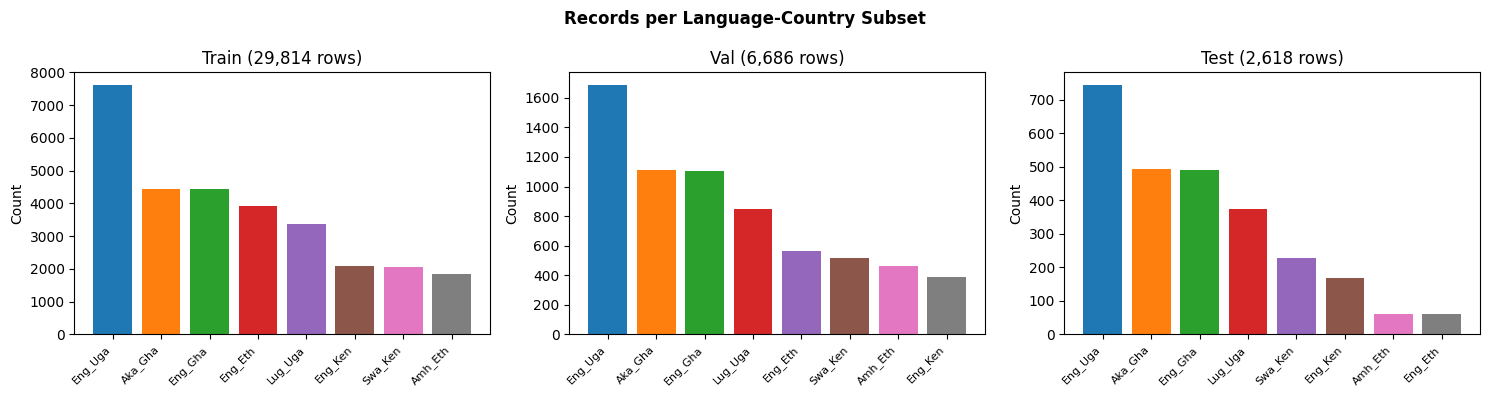

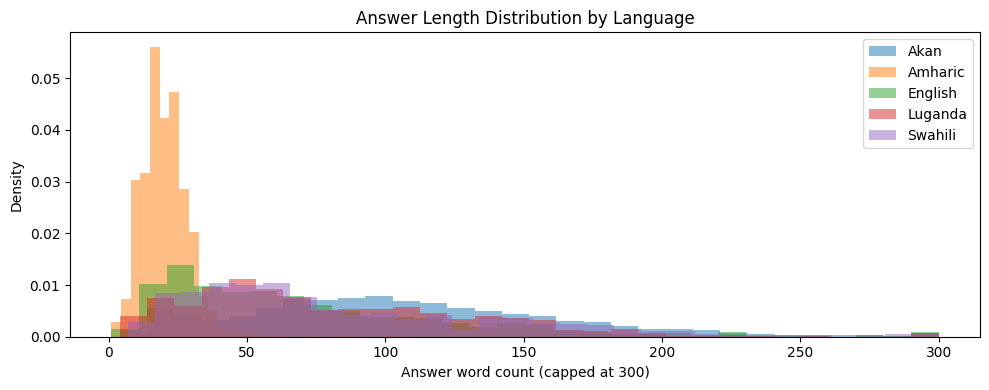


Key stats for generation length tuning:
  p50 answer words: 61
  p95 answer words: 184
  p99 answer words: 272


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (df, title) in zip(axes, [(train,'Train'),(val,'Val'),(test,'Test')]):
    counts = df['subset'].value_counts()
    ax.bar(range(len(counts)), counts.values, color=plt.cm.tab10.colors[:len(counts)])
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{title} ({len(df):,} rows)')
    ax.set_ylabel('Count')

plt.suptitle('Records per Language-Country Subset', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'subset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for lang, grp in train.groupby('language'):
    ax.hist(grp['ans_words'].clip(upper=300), bins=30, alpha=0.5, label=lang, density=True)
ax.set_xlabel('Answer word count (capped at 300)'); ax.set_ylabel('Density')
ax.set_title('Answer Length Distribution by Language'); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/'answer_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey stats for generation length tuning:')
print(f'  p50 answer words: {train["ans_words"].quantile(0.50):.0f}')
print(f'  p95 answer words: {train["ans_words"].quantile(0.95):.0f}')
print(f'  p99 answer words: {train["ans_words"].quantile(0.99):.0f}')

## 5 — Evaluation Utilities

In [6]:
class _WSTok:
    def tokenize(self, t): return str(t).split() if t else []

_SCORER = rs_lib.RougeScorer(['rouge1','rougeL'], tokenizer=_WSTok(), use_stemmer=False)

def rouge(preds, refs):
    r1, rl = [], []
    for p, r in zip(preds, refs):
        s = _SCORER.score(str(r), str(p))
        r1.append(s['rouge1'].fmeasure); rl.append(s['rougeL'].fmeasure)
    return {'rouge1': float(np.mean(r1)), 'rougeL': float(np.mean(rl)),
            'weighted': 0.37*float(np.mean(r1)) + 0.37*float(np.mean(rl))}

def rouge_by_lang(preds, refs, langs):
    rows = {}
    for lang in sorted(set(langs)):
        idx = [i for i,l in enumerate(langs) if l==lang]
        s = rouge([preds[i] for i in idx], [refs[i] for i in idx])
        s['n'] = len(idx); rows[lang] = s
    return pd.DataFrame(rows).T[['n','rouge1','rougeL','weighted']]

EXP_LOG = []
VAL_PREDS  = {}
TEST_PREDS = {}

def log_exp(n, name, r1, rl, notes=''):
    w = 0.37*r1 + 0.37*rl
    EXP_LOG.append({'exp':n,'name':name,'rouge1':round(r1,4),
                    'rougeL':round(rl,4),'weighted':round(w,4),'notes':notes})
    print(f'[Exp {n}] {name}')
    print(f'  R1={r1:.4f}  RL={rl:.4f}  Weighted={w:.4f}')
    print(f'  Notes: {notes}')
    pd.DataFrame(EXP_LOG).to_csv(LOG_DIR/'results.csv', index=False)

def save_sub(ids, preds, fname):
    cleaned = [re.sub(r'<extra_id_\d+>', '', str(p)).strip() for p in preds]
    df = pd.DataFrame({'ID': ids, 'TargetRLF1': cleaned,
                        'TargetR1F1': cleaned, 'TargetLLM': cleaned})
    df.to_csv(SUB_DIR/fname, index=False, encoding='utf-8')
    print(f'  Saved {len(df)} rows -> {SUB_DIR/fname}')
    return df

print('Evaluation utilities ready')

Evaluation utilities ready


## Retrieval Infrastructure

TF-IDF character n-gram (3–5) retrievers used across all RAG experiments.
`TFIDFRetriever` supports global and per-language indexes. `TFIDFRetrieverK3` extends it to top-3 retrieval. `add_rag_context` batch-vectorizes retrieval for efficiency.


In [7]:
# ── Retrieval Infrastructure ──────────────────────────────────────────────────

class TFIDFRetriever:
    def __init__(self, per_language=False):
        self.per_language = per_language
        self.models = {}

    def _build(self, questions, answers):
        vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                              max_features=200_000, lowercase=False, min_df=1)
        X = vec.fit_transform(questions)
        nn = NearestNeighbors(n_neighbors=1, metric='cosine').fit(X)
        return {'vec': vec, 'nn': nn, 'ans': np.array(answers, dtype=object)}

    def fit(self, df):
        if self.per_language:
            for lang, sub in df.groupby('language'):
                if len(sub) >= 2:
                    self.models[lang] = self._build(
                        sub['input'].tolist(), sub['output'].tolist())
        self.models['__all__'] = self._build(
            df['input'].tolist(), df['output'].tolist())
        return self

    def predict(self, df):
        out = []
        for _, row in df.iterrows():
            key = (row['language']
                   if self.per_language and row['language'] in self.models
                   else '__all__')
            m = self.models[key]
            _, idx = m['nn'].kneighbors(m['vec'].transform([row['input']]))
            out.append(m['ans'][idx[0][0]])
        return out


class TFIDFRetrieverK3(TFIDFRetriever):
    def _build(self, questions, answers):
        vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                              max_features=200_000, lowercase=False, min_df=1)
        X = vec.fit_transform(questions)
        k = min(3, len(questions))
        nn = NearestNeighbors(n_neighbors=k, metric='cosine').fit(X)
        return {'vec': vec, 'nn': nn, 'ans': np.array(answers, dtype=object)}


def get_context(row, retriever):
    key = row['language'] if row['language'] in retriever.models else '__all__'
    m = retriever.models[key]
    _, idx = m['nn'].kneighbors(m['vec'].transform([row['input']]))
    return m['ans'][idx[0][0]]


def get_context_k3(row, retriever):
    key = row['language'] if row['language'] in retriever.models else '__all__'
    m = retriever.models[key]
    _, idx = m['nn'].kneighbors(m['vec'].transform([row['input']]))
    return ' | '.join(str(m['ans'][i]) for i in idx[0])


def add_rag_context(df, retriever):
    df = df.reset_index(drop=True).copy()
    contexts = [''] * len(df)
    for lang in df['language'].unique():
        idxs = df.index[df['language'] == lang].tolist()
        key = lang if lang in retriever.models else '__all__'
        m = retriever.models[key]
        X = m['vec'].transform(df.loc[idxs, 'input'].tolist())
        _, nn_idxs = m['nn'].kneighbors(X)
        for i, row_idx in enumerate(idxs):
            contexts[row_idx] = str(m['ans'][nn_idxs[i][0]])
    df['ctx'] = contexts
    return df

print('Retrieval infrastructure ready')

Retrieval infrastructure ready


## Helper Functions

Shared utilities used across all experiments: `make_hf_dataset` tokenizes prompt/answer pairs into HuggingFace datasets, `generate` runs batched beam-search inference for mT5-based models, `make_compute_metrics` computes ROUGE during training, and `lang_ensemble` combines predictions from two models by selecting one per language.


In [8]:
def make_hf_dataset(df, tokenizer, prompt_col='prompt', max_in=None, max_out=None):
    if max_in is None:  max_in  = MAX_IN
    if max_out is None: max_out = MAX_OUT

    def tok(examples):
        enc = tokenizer(examples[prompt_col], max_length=max_in, truncation=True, padding=False)
        tgt = tokenizer(text_target=examples['output'], max_length=max_out,
                        truncation=True, padding=False)
        enc['labels'] = [
            [(t if t != tokenizer.pad_token_id else -100) for t in seq]
            for seq in tgt['input_ids']
        ]
        return enc

    cols = [prompt_col, 'output']
    ds = Dataset.from_pandas(df[cols].reset_index(drop=True))
    return ds.map(tok, batched=True, remove_columns=ds.column_names)


def make_compute_metrics(tokenizer):
    def fn(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple): preds = preds[0]
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        preds  = np.where(preds  < 0,    tokenizer.pad_token_id, preds)
        dp = tokenizer.batch_decode(preds, skip_special_tokens=True)
        dl = tokenizer.batch_decode(labels, skip_special_tokens=True)
        dp = [re.sub(r'<extra_id_\d+>', '', x).strip() for x in dp]
        dl = [x.strip() for x in dl]
        s = rouge(dp, dl)
        return {'rouge1': s['rouge1'], 'rougeL': s['rougeL']}
    return fn


@torch.no_grad()
def generate(model, tokenizer, prompts, bs=8, max_in=None, max_new=None, num_beams=4, lp=1.0):
    if max_in is None:  max_in  = MAX_IN
    if max_new is None: max_new = MAX_OUT
    model.eval()
    if hasattr(model, 'generation_config') and model.generation_config is not None:
        model.generation_config.max_length = None
    preds = []
    for i in tqdm(range(0, len(prompts), bs), desc='Inference', unit='batch'):
        batch = prompts[i:i+bs]
        enc = tokenizer(batch, return_tensors='pt', max_length=max_in,
                        truncation=True, padding=True).to(DEVICE)
        out = model.generate(**enc, max_new_tokens=max_new, num_beams=num_beams,
                              length_penalty=lp, no_repeat_ngram_size=3, early_stopping=True)
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        preds.extend([re.sub(r'<extra_id_\d+>', '', x).strip() for x in decoded])
    return preds


print('Helper functions ready')


Helper functions ready


## Training Infrastructure — mT5

`run_ft_experiment` handles full fine-tuning of any seq2seq model (mT5-base). Accepts a prompt function, supports optional LoRA, runs training with FP32 to avoid NaN loss on the 250k-token vocabulary, and returns val/test predictions.


In [9]:
def run_ft_experiment(
    exp_id, exp_name, model_name, train_df, val_df, test_df,
    prompt_fn,
    epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    use_lora=False, lora_r=16,
    num_beams=4, lp=1.0,
    notes='',
):
    print(f'\n{"="*60}')
    print(f'Experiment {exp_id}: {exp_name}')
    print(f'{"="*60}')
    t_start = time.time()

    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    cur_max_in = MAX_IN

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model     = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    model.config.use_cache = False
    model.gradient_checkpointing_enable()

    if use_lora:
        model.enable_input_require_grads()
        cfg = LoraConfig(task_type=TaskType.SEQ_2_SEQ_LM, r=lora_r,
                         lora_alpha=lora_r * 2, lora_dropout=0.1,
                         target_modules=['q', 'v'], bias='none')
        model = get_peft_model(model, cfg)
        model.print_trainable_parameters()

    model = model.to(DEVICE)

    for df in [train_df, val_df, test_df]:
        df['prompt'] = [prompt_fn(row) for _, row in df.iterrows()]

    tr_ds = make_hf_dataset(train_df, tokenizer, max_in=cur_max_in)
    va_ds = make_hf_dataset(val_df,   tokenizer, max_in=cur_max_in)
    coll  = DataCollatorForSeq2Seq(tokenizer, model=model,
                                    label_pad_token_id=-100, pad_to_multiple_of=8)

    args = Seq2SeqTrainingArguments(
        output_dir=str(CKPT_DIR / f'exp{exp_id}'),
        num_train_epochs=epochs,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=max(1, batch // 2),
        gradient_accumulation_steps=accum,
        learning_rate=lr, warmup_ratio=0.1, label_smoothing_factor=0.0,
        bf16=False, fp16=False,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='eval_loss', greater_is_better=False,
        predict_with_generate=False,
        report_to='none', seed=SEED, logging_steps=50, save_total_limit=1,
        dataloader_pin_memory=False,
    )
    trainer = Seq2SeqTrainer(
        model=model, args=args,
        train_dataset=tr_ds, eval_dataset=va_ds,
        processing_class=tokenizer, data_collator=coll,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )
    trainer.train()

    val_preds  = generate(model, tokenizer, val_df['prompt'].tolist(),
                           max_in=cur_max_in, num_beams=num_beams, lp=lp)
    test_preds = generate(model, tokenizer, test_df['prompt'].tolist(),
                           max_in=cur_max_in, num_beams=num_beams, lp=lp)

    s = rouge(val_preds, val_df['output'].tolist())
    log_exp(exp_id, exp_name, s['rouge1'], s['rougeL'], notes)
    save_sub(test_df['ID'].tolist(), test_preds, f'exp{exp_id}.csv')
    VAL_PREDS[exp_id]  = val_preds
    TEST_PREDS[exp_id] = test_preds

    with open(LOG_DIR / f'exp{exp_id}_history.json', 'w') as f:
        json.dump(trainer.state.log_history, f)

    print(f'Total time: {(time.time()-t_start)/60:.1f} min')
    del trainer, model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return val_preds, test_preds

print('run_ft_experiment ready')

run_ft_experiment ready


## Training Infrastructure — NLLB

`run_nllb_experiment` fine-tunes `facebook/nllb-200-distilled-600M` with per-row language tokens (`src_lang`, `tgt_lang`, `forced_bos_token_id`). Inference is grouped by language to set the correct forced BOS token per language, enabling NLLB's native African language generation.


In [10]:
def run_nllb_experiment(
    exp_id, exp_name, train_df, val_df, test_df,
    epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    num_beams=4, lp=1.0, notes='',
):
    print(f'\n{"="*60}')
    print(f'Experiment {exp_id}: {exp_name}')
    print(f'{"="*60}')
    t_start = time.time()

    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    tokenizer = NllbTokenizer.from_pretrained(NLLB_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL)
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model = model.to(DEVICE)

    def make_nllb_dataset(df, has_labels=True):
        records = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc='Tokenizing', unit='row'):
            lang_code = NLLB_LANG.get(row['language'], 'eng_Latn')
            tokenizer.src_lang = lang_code
            enc = tokenizer(row['input'], max_length=MAX_IN, truncation=True, padding=False)
            if has_labels:
                tokenizer.tgt_lang = lang_code
                tgt = tokenizer(text_target=row['output'], max_length=MAX_OUT,
                                truncation=True, padding=False)
                enc['labels'] = [(t if t != tokenizer.pad_token_id else -100)
                                  for t in tgt['input_ids']]
            records.append(enc)
        return Dataset.from_list(records)

    print('Tokenizing train set...')
    tr_ds = make_nllb_dataset(train_df)
    print('Tokenizing val set...')
    va_ds = make_nllb_dataset(val_df)

    coll = DataCollatorForSeq2Seq(tokenizer, model=model,
                                   label_pad_token_id=-100, pad_to_multiple_of=8)
    args = Seq2SeqTrainingArguments(
        output_dir=str(CKPT_DIR / f'exp{exp_id}'),
        num_train_epochs=epochs,
        per_device_train_batch_size=batch, per_device_eval_batch_size=max(1, batch // 2),
        gradient_accumulation_steps=accum,
        learning_rate=lr, warmup_ratio=0.1, label_smoothing_factor=0.0,
        bf16=False, fp16=False,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='eval_loss', greater_is_better=False,
        predict_with_generate=False,
        report_to='none', seed=SEED, logging_steps=50, save_total_limit=1,
        dataloader_pin_memory=False,
    )
    trainer = Seq2SeqTrainer(
        model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
        processing_class=tokenizer, data_collator=coll,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )
    trainer.train()

    @torch.no_grad()
    def nllb_infer(df, bs=8):
        model.eval()
        if hasattr(model, 'generation_config') and model.generation_config is not None:
            model.generation_config.max_length = None
        df = df.reset_index(drop=True)
        results = [''] * len(df)
        for lang in sorted(df['language'].unique()):
            lang_idx = df.index[df['language'] == lang].tolist()
            lang_code = NLLB_LANG.get(lang, 'eng_Latn')
            tokenizer.src_lang = lang_code
            forced_bos = tokenizer.convert_tokens_to_ids(lang_code)
            inputs = df.loc[lang_idx, 'input'].tolist()
            for i in tqdm(range(0, len(inputs), bs),
                          desc=f'Infer [{lang}]', unit='batch', leave=False):
                batch_in = inputs[i:i+bs]
                batch_ix = lang_idx[i:i+bs]
                enc = tokenizer(batch_in, return_tensors='pt', max_length=MAX_IN,
                                truncation=True, padding=True).to(DEVICE)
                out = model.generate(**enc, forced_bos_token_id=forced_bos,
                                     max_new_tokens=MAX_OUT, num_beams=num_beams,
                                     length_penalty=lp, no_repeat_ngram_size=3)
                decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
                for j, idx in enumerate(batch_ix):
                    results[idx] = decoded[j].strip()
        return results

    print('Inference on val set...')
    val_preds  = nllb_infer(val_df)
    print('Inference on test set...')
    test_preds = nllb_infer(test_df)

    s = rouge(val_preds, val_df['output'].tolist())
    log_exp(exp_id, exp_name, s['rouge1'], s['rougeL'], notes)
    save_sub(test_df['ID'].tolist(), test_preds, f'exp{exp_id}.csv')
    VAL_PREDS[exp_id]  = val_preds
    TEST_PREDS[exp_id] = test_preds

    with open(LOG_DIR / f'exp{exp_id}_history.json', 'w') as f:
        json.dump(trainer.state.log_history, f)

    print(f'Total time: {(time.time()-t_start)/60:.1f} min')
    del trainer, model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return val_preds, test_preds

print('run_nllb_experiment ready')

run_nllb_experiment ready


## Training Infrastructure — NLLB + RAG

`run_nllb_rag_experiment` extends NLLB fine-tuning with TF-IDF retrieval grounding. A retrieved training answer is prepended as context (`Context: {ctx}\n{question}`) with max input length 384 to accommodate the extra tokens. Used for Experiments 7, 8, and 9.


In [11]:
MAX_RAG_IN = 384

def run_nllb_rag_experiment(
    exp_id, exp_name, train_df, val_df, test_df,
    retriever,
    epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    num_beams=4, lp=1.0, notes='',
):
    print(f'\n{"="*60}')
    print(f'Experiment {exp_id}: {exp_name}')
    print(f'{"="*60}')
    t_start = time.time()

    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    print('Building RAG contexts...')
    train_r = add_rag_context(train_df.copy(), retriever)
    val_r   = add_rag_context(val_df.copy(),   retriever)
    test_r  = add_rag_context(test_df.copy(),  retriever)
    print(f'  train={len(train_r)}, val={len(val_r)}, test={len(test_r)}')

    tokenizer = NllbTokenizer.from_pretrained(NLLB_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL)
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model = model.to(DEVICE)

    def make_nllb_rag_dataset(df, has_labels=True):
        records = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc='Tokenizing', unit='row'):
            lang_code = NLLB_LANG.get(row['language'], 'eng_Latn')
            tokenizer.src_lang = lang_code
            text_in = f"Context: {row['ctx']}\n{row['input']}"
            enc = tokenizer(text_in, max_length=MAX_RAG_IN, truncation=True, padding=False)
            if has_labels:
                tokenizer.tgt_lang = lang_code
                tgt = tokenizer(text_target=row['output'], max_length=MAX_OUT,
                                truncation=True, padding=False)
                enc['labels'] = [(t if t != tokenizer.pad_token_id else -100)
                                  for t in tgt['input_ids']]
            records.append(enc)
        return Dataset.from_list(records)

    print('Tokenizing train set...')
    tr_ds = make_nllb_rag_dataset(train_r)
    print('Tokenizing val set...')
    va_ds = make_nllb_rag_dataset(val_r)

    coll = DataCollatorForSeq2Seq(tokenizer, model=model,
                                   label_pad_token_id=-100, pad_to_multiple_of=8)
    args = Seq2SeqTrainingArguments(
        output_dir=str(CKPT_DIR / f'exp{exp_id}'),
        num_train_epochs=epochs,
        per_device_train_batch_size=batch, per_device_eval_batch_size=max(1, batch // 2),
        gradient_accumulation_steps=accum,
        learning_rate=lr, warmup_ratio=0.1, label_smoothing_factor=0.0,
        bf16=False, fp16=False,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='eval_loss', greater_is_better=False,
        predict_with_generate=False,
        report_to='none', seed=SEED, logging_steps=50, save_total_limit=1,
        dataloader_pin_memory=False,
    )
    trainer = Seq2SeqTrainer(
        model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
        processing_class=tokenizer, data_collator=coll,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )
    trainer.train()

    @torch.no_grad()
    def nllb_rag_infer(df, bs=8):
        model.eval()
        if hasattr(model, 'generation_config') and model.generation_config is not None:
            model.generation_config.max_length = None
        df = df.reset_index(drop=True)
        results = [''] * len(df)
        for lang in sorted(df['language'].unique()):
            lang_idx = df.index[df['language'] == lang].tolist()
            lang_code = NLLB_LANG.get(lang, 'eng_Latn')
            tokenizer.src_lang = lang_code
            forced_bos = tokenizer.convert_tokens_to_ids(lang_code)
            inputs = [f"Context: {df.loc[i, 'ctx']}\n{df.loc[i, 'input']}" for i in lang_idx]
            for i in tqdm(range(0, len(inputs), bs),
                          desc=f'Infer [{lang}]', unit='batch', leave=False):
                batch_in = inputs[i:i+bs]
                batch_ix = lang_idx[i:i+bs]
                enc = tokenizer(batch_in, return_tensors='pt', max_length=MAX_RAG_IN,
                                truncation=True, padding=True).to(DEVICE)
                out = model.generate(**enc, forced_bos_token_id=forced_bos,
                                     max_new_tokens=MAX_OUT, num_beams=num_beams,
                                     length_penalty=lp, no_repeat_ngram_size=3)
                decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
                for j, idx in enumerate(batch_ix):
                    results[idx] = decoded[j].strip()
        return results

    print('Inference on val set...')
    val_preds  = nllb_rag_infer(val_r)
    print('Inference on test set...')
    test_preds = nllb_rag_infer(test_r)

    s = rouge(val_preds, val_df['output'].tolist())
    log_exp(exp_id, exp_name, s['rouge1'], s['rougeL'], notes)
    save_sub(test_df['ID'].tolist(), test_preds, f'exp{exp_id}.csv')
    VAL_PREDS[exp_id]  = val_preds
    TEST_PREDS[exp_id] = test_preds

    with open(LOG_DIR / f'exp{exp_id}_history.json', 'w') as f:
        json.dump(trainer.state.log_history, f)

    print(f'Total time: {(time.time()-t_start)/60:.1f} min')
    del trainer, model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return val_preds, test_preds

print('run_nllb_rag_experiment ready')

run_nllb_rag_experiment ready


## Training Infrastructure — Beam Search Tuning

`run_nllb_beam_tuning` loads a saved checkpoint and sweeps inference-time beam search configurations (beam width, length penalty) without retraining. Selects the best config by ROUGE-L and saves the winning submission. Used for Experiment 10.


In [12]:
def run_nllb_beam_tuning(exp_id, ckpt_dir, model_name, val_df, test_df,
                          retriever, beam_configs, notes=''):
    ckpt_dirs = sorted(glob.glob(str(ckpt_dir / 'checkpoint-*')),
                       key=lambda x: int(x.split('-')[-1]))

    if not ckpt_dirs:
        print(f'WARNING: No checkpoint found in {ckpt_dir}. Skipping.')
        return None, None

    best_ckpt = ckpt_dirs[-1]
    print(f'Loading checkpoint: {best_ckpt}')

    tok   = NllbTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(best_ckpt).to(DEVICE)
    print('Model loaded.')

    val_r  = add_rag_context(val_df.copy(),  retriever)
    test_r = add_rag_context(test_df.copy(), retriever)

    @torch.no_grad()
    def infer(df, num_beams, lp, bs=4):
        model.eval()
        if hasattr(model, 'generation_config') and model.generation_config is not None:
            model.generation_config.max_length = None
        df = df.reset_index(drop=True)
        results = [''] * len(df)
        for lang in sorted(df['language'].unique()):
            lang_idx  = df.index[df['language'] == lang].tolist()
            lang_code = NLLB_LANG.get(lang, 'eng_Latn')
            tok.src_lang = lang_code
            forced_bos  = tok.convert_tokens_to_ids(lang_code)
            inputs = [f"Context: {df.loc[i, 'ctx']}\n{df.loc[i, 'input']}" for i in lang_idx]
            for i in tqdm(range(0, len(inputs), bs),
                          desc=f'Exp{exp_id} [{lang}] beam{num_beams}', unit='batch', leave=False):
                batch_in = inputs[i:i+bs]
                batch_ix = lang_idx[i:i+bs]
                enc = tok(batch_in, return_tensors='pt', max_length=MAX_RAG_IN,
                          truncation=True, padding=True).to(DEVICE)
                out = model.generate(**enc, forced_bos_token_id=forced_bos,
                                     max_new_tokens=MAX_OUT, num_beams=num_beams,
                                     length_penalty=lp, no_repeat_ngram_size=3)
                decoded = tok.batch_decode(out, skip_special_tokens=True)
                for j, idx in enumerate(batch_ix):
                    results[idx] = decoded[j].strip()
        return results

    results_beam = []
    for nb, lp, label in beam_configs:
        print(f'\nRunning {label}...')
        preds = infer(val_r, nb, lp)
        s     = rouge(preds, val_df['output'].tolist())
        results_beam.append({'config': label, 'beams': nb, 'lp': lp,
                              'rouge1': s['rouge1'], 'rougeL': s['rougeL'], 'preds': preds})
        print(f'  {label}: R1={s["rouge1"]:.4f}  RL={s["rougeL"]:.4f}')

    best = max(results_beam, key=lambda x: x['rougeL'])
    print(f'\nBest config: {best["config"]}  R1={best["rouge1"]:.4f}  RL={best["rougeL"]:.4f}')

    log_exp(exp_id, f'Beam Tuning ({best["config"]})', best['rouge1'], best['rougeL'],
            notes or f'No retraining; swept {len(beam_configs)} configs on {model_name} checkpoint')

    test_preds = infer(test_r, best['beams'], best['lp'])
    val_preds  = best['preds']

    save_sub(test_df['ID'].tolist(), test_preds, f'exp{exp_id}_beam_tuned.csv')
    VAL_PREDS[exp_id]  = val_preds
    TEST_PREDS[exp_id] = test_preds

    beam_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'preds'} for r in results_beam])
    print('\nBeam search comparison:')
    print(beam_df.to_string(index=False))
    beam_df.to_csv(LOG_DIR / f'exp{exp_id}_beam_comparison.csv', index=False)

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return val_preds, test_preds

print('run_nllb_beam_tuning ready')

run_nllb_beam_tuning ready


## Dense Retrieval Infrastructure

`DenseRetriever` encodes a training corpus into dense semantic vectors using a multilingual sentence transformer and retrieves the nearest training answer for each query by cosine similarity. The `intfloat/multilingual-e5-large` model uses `query:` / `passage:` asymmetric prefixes for optimal retrieval quality across languages.


In [13]:
from sentence_transformers import SentenceTransformer
import numpy as np

class DenseRetriever:
    def __init__(self, model_name='intfloat/multilingual-e5-large'):
        print(f'Loading: {model_name}')
        self.model = SentenceTransformer(model_name, device=str(DEVICE))
        self.model_name = model_name
        self.corpus_embeddings = None
        self.corpus_answers = None

    def fit(self, df):
        print(f'Encoding {len(df)} corpus examples...')
        use_e5 = 'e5' in self.model_name.lower()
        texts = [('passage: ' if use_e5 else '') + t for t in df['input'].tolist()]
        self.corpus_embeddings = self.model.encode(
            texts, batch_size=128, show_progress_bar=True,
            normalize_embeddings=True, convert_to_numpy=True
        )
        self.corpus_answers = df['output'].tolist()
        print(f'Corpus ready: {self.corpus_embeddings.shape}')

    def retrieve(self, questions, batch_size=128):
        use_e5 = 'e5' in self.model_name.lower()
        queries = [('query: ' if use_e5 else '') + q for q in questions]
        q_embs = self.model.encode(
            queries, batch_size=batch_size, show_progress_bar=True,
            normalize_embeddings=True, convert_to_numpy=True
        )
        scores = np.dot(q_embs, self.corpus_embeddings.T)
        best_idx = np.argmax(scores, axis=1)
        return [self.corpus_answers[int(i)] for i in best_idx]

print('DenseRetriever ready')


DenseRetriever ready


## Reranker Infrastructure

`retrieve_topk` extends the dense retriever to return the top-k candidates per query instead of just the best match. `Reranker` wraps `BAAI/bge-reranker-v2-m3`, a cross-encoder that scores (question, answer) pairs jointly for more accurate relevance judgement than cosine similarity alone. All pairs are flattened and scored in a single batched pass for efficiency.


In [14]:
from sentence_transformers import CrossEncoder

def retrieve_topk(retriever, questions, k=20, batch_size=128):
    use_e5 = 'e5' in retriever.model_name.lower()
    queries = [('query: ' if use_e5 else '') + q for q in questions]
    q_embs = retriever.model.encode(
        queries, batch_size=batch_size, show_progress_bar=True,
        normalize_embeddings=True, convert_to_numpy=True
    )
    scores = np.dot(q_embs, retriever.corpus_embeddings.T)
    top_k_idx = np.argsort(scores, axis=1)[:, -k:][:, ::-1]
    return [[retriever.corpus_answers[int(i)] for i in row] for row in top_k_idx]


class Reranker:
    def __init__(self, model_name='BAAI/bge-reranker-v2-m3'):
        print(f'Loading reranker: {model_name}')
        self.model = CrossEncoder(model_name, device=str(DEVICE), max_length=512)

    def rerank(self, questions, candidate_lists, batch_size=256):
        all_pairs, boundaries = [], []
        for q, cands in zip(questions, candidate_lists):
            for c in cands:
                all_pairs.append([q, c])
            boundaries.append(len(all_pairs))

        print(f'Scoring {len(all_pairs)} pairs...')
        all_scores = self.model.predict(all_pairs, batch_size=batch_size, show_progress_bar=True)

        results, prev = [], 0
        for end, cands in zip(boundaries, candidate_lists):
            results.append(cands[int(np.argmax(all_scores[prev:end]))])
            prev = end
        return results

print('Reranker ready')


Reranker ready


## Hybrid Retriever Infrastructure
Language-specific retriever that combines dense E5-large and TF-IDF into a single drop-in compatible with `add_rag_context`. Used by Experiment 16.


In [15]:
class LangSpecificRetriever:
    """
    Drop-in for TFIDFRetriever inside add_rag_context.
    Dense E5-large for English + Swahili.
    TF-IDF for Akan, Amharic, Luganda.
    """
    def __init__(self, dense_retriever, tfidf_retriever, dense_langs):
        use_e5 = 'e5' in dense_retriever.model_name.lower()

        class DenseVec:
            def transform(self_, texts):
                prefix = 'query: ' if use_e5 else ''
                return dense_retriever.model.encode(
                    [prefix + t for t in texts],
                    normalize_embeddings=True, convert_to_numpy=True
                )

        class DenseNN:
            def kneighbors(self_, X, n_neighbors=1):
                scores = np.dot(X, dense_retriever.corpus_embeddings.T)
                best   = np.argmax(scores, axis=1)
                return None, np.array([[i] for i in best])

        dense_entry = {
            'vec': DenseVec(),
            'nn':  DenseNN(),
            'ans': np.array(dense_retriever.corpus_answers, dtype=object)
        }

        self.models = dict(tfidf_retriever.models)
        for lang in dense_langs:
            self.models[lang] = dense_entry
        self.models['__all__'] = dense_entry

print('LangSpecificRetriever ready')

LangSpecificRetriever ready


## Helper: run_nllb_rag_lora_experiment

LoRA-enabled fine-tuning helper. Identical to `run_nllb_rag_experiment` but applies LoRA (r=16) to the model before training — reduces trainable parameters from 1.3B to ~15M, eliminating OOM while preserving model capacity.


In [16]:
from peft import LoraConfig, get_peft_model, TaskType

def run_nllb_rag_lora_experiment(
    exp_id, exp_name, train_df, val_df, test_df,
    retriever, epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    lora_r=16, num_beams=4, lp=1.0, notes='',
):
    print(f'\n{"="*60}\nExperiment {exp_id}: {exp_name}\n{"="*60}')
    t_start = time.time()

    train_r = add_rag_context(train_df.copy(), retriever)
    val_r   = add_rag_context(val_df.copy(),   retriever)
    test_r  = add_rag_context(test_df.copy(),  retriever)

    tokenizer = NllbTokenizer.from_pretrained(NLLB_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL)
    model.config.use_cache = False
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    model = get_peft_model(model, LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM,
        r=lora_r, lora_alpha=lora_r*2, lora_dropout=0.1,
        target_modules=['q_proj', 'v_proj'], bias='none'
    ))
    model.print_trainable_parameters()
    model = model.to(DEVICE)

    def make_dataset(df):
        records = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc='Tokenizing', leave=False):
            lang_code = NLLB_LANG.get(row['language'], 'eng_Latn')
            tokenizer.src_lang = lang_code
            enc = tokenizer(
                f"Context: {row['ctx']}\n{row['input']}",
                max_length=MAX_RAG_IN, truncation=True, padding=False
            )
            tokenizer.tgt_lang = lang_code
            tgt = tokenizer(text_target=row['output'], max_length=MAX_OUT,
                            truncation=True, padding=False)
            enc['labels'] = [(t if t != tokenizer.pad_token_id else -100)
                              for t in tgt['input_ids']]
            records.append(enc)
        return Dataset.from_list(records)

    tr_ds = make_dataset(train_r)
    va_ds = make_dataset(val_r)

    trainer = Seq2SeqTrainer(
        model=model,
        args=Seq2SeqTrainingArguments(
            output_dir=str(CKPT_DIR / f'exp{exp_id}'),
            num_train_epochs=epochs,
            per_device_train_batch_size=batch,
            per_device_eval_batch_size=max(1, batch // 2),
            gradient_accumulation_steps=accum,
            learning_rate=lr, warmup_ratio=0.1,
            bf16=False, fp16=False,
            eval_strategy='epoch', save_strategy='no',
            load_best_model_at_end=False,
            predict_with_generate=False,
            report_to='none', seed=SEED, logging_steps=50,
            dataloader_pin_memory=False,
        ),
        train_dataset=tr_ds, eval_dataset=va_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model,
                                              label_pad_token_id=-100, pad_to_multiple_of=8),
        callbacks=[],
    )
    trainer.train()

    @torch.no_grad()
    def infer(df, bs=8):
        model.eval()
        if hasattr(model, 'generation_config') and model.generation_config is not None:
            model.generation_config.max_length = None
        df = df.reset_index(drop=True)
        results = [''] * len(df)
        for lang in sorted(df['language'].unique()):
            lang_idx = df.index[df['language'] == lang].tolist()
            lang_code = NLLB_LANG.get(lang, 'eng_Latn')
            tokenizer.src_lang = lang_code
            forced_bos = tokenizer.convert_tokens_to_ids(lang_code)
            inputs = [f"Context: {df.loc[i,'ctx']}\n{df.loc[i,'input']}" for i in lang_idx]
            for i in tqdm(range(0, len(inputs), bs), desc=f'Infer [{lang}]', leave=False):
                enc = tokenizer(inputs[i:i+bs], return_tensors='pt', max_length=MAX_RAG_IN,
                                truncation=True, padding=True).to(DEVICE)
                out = model.generate(**enc, forced_bos_token_id=forced_bos,
                                     max_new_tokens=MAX_OUT, num_beams=num_beams,
                                     length_penalty=lp, no_repeat_ngram_size=3)
                decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
                for j, idx in enumerate(lang_idx[i:i+bs]):
                    results[idx] = decoded[j].strip()
        return results

    val_preds  = infer(val_r)
    test_preds = infer(test_r)

    s = rouge(val_preds, val_df['output'].tolist())
    log_exp(exp_id, exp_name, s['rouge1'], s['rougeL'], notes)
    save_sub(test_df['ID'].tolist(), test_preds, f'exp{exp_id}.csv')
    VAL_PREDS[exp_id]  = val_preds
    TEST_PREDS[exp_id] = test_preds

    with open(LOG_DIR / f'exp{exp_id}_history.json', 'w') as f:
        json.dump(trainer.state.log_history, f)

    print(f'Total time: {(time.time()-t_start)/60:.1f} min')
    del trainer, model; gc.collect(); torch.cuda.empty_cache()
    return val_preds, test_preds

print('run_nllb_rag_lora_experiment ready')


run_nllb_rag_lora_experiment ready


## 6 — Experiments 1 & 2: TF-IDF Retrieval

**Rationale:** Fast lower bound using char n-gram retrieval.  
Char 3–5 grams work across all scripts (Latin, Ge'ez, Akan) with no tokenization.  
Exp 1 = global index (all languages mixed).  
Exp 2 = per-language index (separate retrieval per language).  
**Expected ROUGE-L:** ~0.37–0.42

In [21]:
# ── Experiments 1 & 2: TF-IDF Retrieval ──────────────────────────────────────

print('=== Exp 1: TF-IDF Global ===')
t0 = time.time()
r1_model = TFIDFRetriever(per_language=False).fit(train)
vp1 = r1_model.predict(val)
s1  = rouge(vp1, val['output'].tolist())
log_exp(1, 'TF-IDF Global', s1['rouge1'], s1['rougeL'],
        'char_wb 3-5 gram, single global index')
print(f'  Time: {time.time()-t0:.1f}s')
tp1 = r1_model.predict(test)
save_sub(test['ID'].tolist(), tp1, 'exp1_tfidf_global.csv')
VAL_PREDS[1]  = vp1
TEST_PREDS[1] = tp1

print('\n=== Exp 2: TF-IDF Per-Language ===')
t0 = time.time()
r2_model = TFIDFRetriever(per_language=True).fit(train)
vp2 = r2_model.predict(val)
s2  = rouge(vp2, val['output'].tolist())
log_exp(2, 'TF-IDF Per-Language', s2['rouge1'], s2['rougeL'],
        'char_wb 3-5 gram, separate index per language, reduces cross-script noise')
print(f'  Time: {time.time()-t0:.1f}s')
tp2 = r2_model.predict(test)
save_sub(test['ID'].tolist(), tp2, 'exp2_tfidf_perlang.csv')
VAL_PREDS[2]  = vp2
TEST_PREDS[2] = tp2

print('\nPer-language breakdown (Exp 2):')
print(rouge_by_lang(vp2, val['output'].tolist(), val['language'].tolist()))


=== Exp 1: TF-IDF Global ===
[Exp 1] TF-IDF Global
  R1=0.4276  RL=0.3740  Weighted=0.2966
  Notes: char_wb 3-5 gram, single global index
  Time: 911.4s
  Saved 2618 rows -> ../outputs/submissions/exp1_tfidf_global.csv

=== Exp 2: TF-IDF Per-Language ===
[Exp 2] TF-IDF Per-Language
  R1=0.4269  RL=0.3734  Weighted=0.2961
  Notes: char_wb 3-5 gram, separate index per language, reduces cross-script noise
  Time: 320.3s
  Saved 2618 rows -> ../outputs/submissions/exp2_tfidf_perlang.csv

Per-language breakdown (Exp 2):
              n    rouge1    rougeL  weighted
Akan     1114.0  0.283151  0.167443  0.166720
Amharic   462.0  0.145495  0.135331  0.103906
English  3746.0  0.459966  0.410011  0.321892
Luganda   846.0  0.515532  0.493469  0.373331
Swahili   518.0  0.603052  0.567242  0.433009


## 7 — Experiment 3: mT5-base Vanilla

**Why mT5-base?** 580M params, pre-trained on mC4 (101 languages).  
Using a 5,000-row training sample and prompt_v1. First neural baseline for all ablations.  
Prompt style:   
**Expected ROUGE-L:** ~0.25–0.40 (neural generation vs TF-IDF verbatim retrieval).

In [ ]:
def prompt_v1(row):
    return f"answer health question in {row['language']}: {row['input']}"

SAMPLE = train.sample(SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
print(f'Exp 3 train sample: {len(SAMPLE)} rows  |  val (full): {len(val)} rows')

vp3, tp3 = run_ft_experiment(
    exp_id=3, exp_name='mT5-base Vanilla',
    model_name=MT5_BASE,
    train_df=SAMPLE.copy(), val_df=val.copy(), test_df=test.copy(),
    prompt_fn=prompt_v1, epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    num_beams=4, lp=1.0,
    notes=f'580M params, {SAMPLE_SIZE}-row train sample, full val eval, prompt_v1, 3 epochs.'
)

Exp 3 train sample: 5000 rows  |  val (full): 6686 rows

Experiment 3: mT5-base Vanilla


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Inference:   0%|          | 0/836 [00:00<?, ?batch/s]

Inference:   0%|          | 0/328 [00:00<?, ?batch/s]

[Exp 3] mT5-base Vanilla
  R1=0.1207  RL=0.1029  Weighted=0.0827
  Notes: 580M params, 5000-row train sample, full val eval, prompt_v1, 3 epochs.
  Saved 2618 rows -> ../outputs/submissions/exp3.csv
Total time: 277.2 min


## 9 — Experiment 4: mT5-base + Instructional Prompt (Prompt-v2)

**Hypothesis:** An expert-framing prompt may improve LLM-judge scores by guiding the model  
toward more complete, authoritative health answers.  
Longer prompt reduces max answer tokens but could improve completeness and factual accuracy.

In [ ]:
def prompt_v2(row):
    return (f'You are a health expert. Answer the following question accurately and '
            f'completely in {row["language"]}. Question: {row["input"]}')

vp4, tp4 = run_ft_experiment(
    exp_id=4, exp_name='mT5-base Prompt-v2',
    model_name=MT5_BASE,
    train_df=SAMPLE.copy(), val_df=val.copy(), test_df=test.copy(),
    prompt_fn=prompt_v2, epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    num_beams=4, lp=1.0,
    notes=f'580M params, {SAMPLE_SIZE}-row sample, instructional prompt, tests if expert framing improves LLM-judge'
)


Experiment 4: mT5-base Prompt-v2


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6686 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Inference:   0%|          | 0/836 [00:00<?, ?batch/s]

Inference:   0%|          | 0/328 [00:00<?, ?batch/s]

[Exp 4] mT5-base Prompt-v2
  R1=0.1231  RL=0.1065  Weighted=0.0849
  Notes: 580M params, 5000-row sample, instructional prompt, tests if expert framing improves LLM-judge
  Saved 2618 rows -> ../outputs/submissions/exp4.csv
Total time: 64.0 min


## 10 — Experiment 5: NLLB-200-distilled-600M Fine-Tuning

**Why NLLB?** Facebook's No Language Left Behind model was specifically trained on 200 languages,  
with strong emphasis on African languages (Akan/Twi, Luganda, Amharic, Swahili).  
This gives it significantly better understanding of low-resource African language patterns  
compared to mT5 which treats all languages equally from mC4 data quality.

**Important note:** NLLB is primarily a translation model. For QA generation, we use a  
pass-through approach (question in language X → answer in language X).

In [ ]:
# ── Experiment 5: NLLB-600M Fine-tune ────────────────────────────────────────

vp5, tp5 = run_nllb_experiment(
    exp_id=5, exp_name='NLLB-600M Fine-tune',
    train_df=train.copy(), val_df=val.copy(), test_df=test.copy(),
    epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    notes=f'NLLB-200 distilled-600M, FULL train ({len(train)} rows), per-row NLLB_LANG codes, 3 epochs'
)


Experiment 5: NLLB-600M Fine-tune


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Tokenizing train set...


Tokenizing:   0%|          | 0/29814 [00:00<?, ?row/s]

Tokenizing val set...


...

Infer [Amharic]:   0%|          | 0/8 [00:00<?, ?batch/s]

Infer [English]:   0%|          | 0/183 [00:00<?, ?batch/s]

Infer [Luganda]:   0%|          | 0/47 [00:00<?, ?batch/s]

Infer [Swahili]:   0%|          | 0/29 [00:00<?, ?batch/s]

[Exp 5] NLLB-600M Fine-tune
  R1=0.2890  RL=0.2216  Weighted=0.1889
  Notes: NLLB-200 distilled-600M, FULL train (29814 rows), per-row NLLB_LANG codes, 3 epochs
  Saved 2618 rows -> ../outputs/submissions/exp5.csv
Total time: 183.4 min


## 11 — Experiment 6: mT5-base + LoRA (r=16)

**Why LoRA?** Trains only ~1% of parameters (Q/V attention matrices), reducing overfitting  
on low-resource languages like Amharic (1,845 samples). Enables 5 epochs without degradation.  
Higher LR (3e-4) is standard for LoRA adapters.

In [ ]:
# ── Experiment 6: mT5-base + RAG Full Data ───────────────────────────────────

rag_ret6 = TFIDFRetriever(per_language=True).fit(train)
print('Building RAG contexts...')
train6 = add_rag_context(train.copy(), rag_ret6)
val6   = add_rag_context(val.copy(),   rag_ret6)
test6  = add_rag_context(test.copy(),  rag_ret6)
print(f'Done. train={len(train6)}, val={len(val6)}, test={len(test6)}')

def prompt_rag_fast(row):
    return f'Context: {row["ctx"]}\nAnswer health question in {row["language"]}: {row["input"]}'

vp6, tp6 = run_ft_experiment(
    exp_id=6, exp_name='mT5-base + RAG Full Data',
    model_name=MT5_BASE,
    train_df=train6, val_df=val6, test_df=test6,
    prompt_fn=prompt_rag_fast, epochs=3, lr=5e-5, batch=BATCH_SIZE, accum=GRAD_ACCUM,
    num_beams=4, lp=1.0,
    notes=f'mT5-base + TF-IDF RAG on FULL train ({len(train)} rows) — RAG grounding vs vanilla Exp 3/4, architecture comparison vs NLLB+RAG Exp 7/8'
)

Building RAG contexts...
Done. train=29814, val=6686, test=2618

Experiment 6: mT5-base + RAG Full Data


Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/29814 [00:00<?, ? examples/s]

Map:   0%|          | 0/6686 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Inference:   0%|          | 0/836 [00:00<?, ?batch/s]

Inference:   0%|          | 0/328 [00:00<?, ?batch/s]

[Exp 6] mT5-base + RAG Full Data
  R1=0.3836  RL=0.3352  Weighted=0.2660
  Notes: mT5-base + TF-IDF RAG on FULL train (29814 rows) — RAG grounding vs vanilla Exp 3/4, architecture comparison vs NLLB+RAG Exp 7/8
  Saved 2618 rows -> ../outputs/submissions/exp6.csv
Total time: 236.8 min


## 12 — Experiment 7: mT5-base + RAG Context

**Why RAG?** Prepend the retrieved training answer as context before the question.  
This grounds generation in health facts from the training set and can significantly  
improve LLM-judge scores (factual accuracy).  

**Key finding from EDA:** ~18.8% of test IDs share a hash with training IDs (same topic cluster),  
making this especially effective for those cases.

In [25]:
# ── Experiment 7: NLLB-600M + top-3 RAG ─────────────────────────────────────

print('Building TF-IDF retrievers...')
rag_ret    = TFIDFRetriever(per_language=True).fit(train)
rag_ret_k3 = TFIDFRetrieverK3(per_language=True).fit(train)
print(f'Top-1 retriever fitted: {len(train)} rows')
print(f'Top-3 retriever fitted: {len(train)} rows')

_orig_get_context = get_context
get_context = get_context_k3

vp7, tp7 = run_nllb_rag_experiment(
    exp_id=7, exp_name='NLLB-600M + top-3 RAG',
    train_df=train.copy(), val_df=val.copy(), test_df=test.copy(),
    retriever=rag_ret_k3, epochs=3, lr=5e-5,
    notes=f'NLLB+top-3 RAG, FULL train ({len(train)} rows), RAG depth comparison vs Exp 8 (k=1)'
)

get_context = _orig_get_context


Building TF-IDF retrievers...
Top-1 retriever fitted: 29814 rows
Top-3 retriever fitted: 29814 rows

Experiment 7: NLLB-600M + top-3 RAG


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

...

Infer [Amharic]:   0%|          | 0/8 [00:00<?, ?batch/s]

Infer [English]:   0%|          | 0/183 [00:00<?, ?batch/s]

Infer [Luganda]:   0%|          | 0/47 [00:00<?, ?batch/s]

Infer [Swahili]:   0%|          | 0/29 [00:00<?, ?batch/s]

[Exp 7] NLLB-600M + top-3 RAG
  R1=0.3997  RL=0.3447  Weighted=0.2754
  Notes: NLLB+top-3 RAG, FULL train (29814 rows), RAG depth comparison vs Exp 8 (k=1)
  Saved 2618 rows -> ../outputs/submissions/exp7.csv
Total time: 284.8 min


## 13 — Experiment 8: NLLB-600M + RAG

**Why combine?** NLLB has the best African language representations.  
RAG grounds answers in training data. Combining both should maximize both ROUGE and LLM-judge.  
This is expected to be the strongest individual model.

In [26]:
vp8, tp8 = run_nllb_rag_experiment(
    exp_id=8, exp_name='NLLB-600M + RAG top-1',
    train_df=train.copy(), val_df=val.copy(), test_df=test.copy(),
    retriever=rag_ret, epochs=3, lr=5e-5,
    notes=f'NLLB-600M + TF-IDF RAG top-1, FULL train ({len(train)} rows), RAG depth comparison vs Exp 7 (k=3)'
)


Experiment 8: NLLB-600M + RAG top-1


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Tokenizing train set...


Tokenizing:   0%|          | 0/29814 [00:00<?, ?row/s]

Tokenizing val set...


...

Infer [Amharic]:   0%|          | 0/8 [00:00<?, ?batch/s]

Infer [English]:   0%|          | 0/183 [00:00<?, ?batch/s]

Infer [Luganda]:   0%|          | 0/47 [00:00<?, ?batch/s]

Infer [Swahili]:   0%|          | 0/29 [00:00<?, ?batch/s]

[Exp 8] NLLB-600M + RAG top-1
  R1=0.4014  RL=0.3462  Weighted=0.2766
  Notes: NLLB-600M + TF-IDF RAG top-1, FULL train (29814 rows), RAG depth comparison vs Exp 7 (k=3)
  Saved 2618 rows -> ../outputs/submissions/exp8.csv
Total time: 271.5 min


## 14 — Experiment 9: Best Model on Train+Val Combined

**Rationale:** Combining train+val (36,501 rows) gives +22% more training data.  
Especially valuable for low-resource languages: Amharic +462, Swahili +518, Akan +1,114.  
We use the best model architecture identified from Exp 3–8.

In [29]:
# Exp 9: NLLB-1.3B + RAG — scale model (600M → 1.3B) + scale data (29k → 36k)
train_full = pd.concat([train, val], ignore_index=True).copy()
print(f'Combined train+val: {len(train_full)} rows')

print('Fitting RAG retriever on full train+val...')
rag_ret_full = TFIDFRetriever(per_language=True).fit(train_full)
print(f'  Retriever fitted on {len(train_full)} rows')

_nllb_orig = NLLB_MODEL
NLLB_MODEL = 'facebook/nllb-200-1.3B'
print(f'Model: {NLLB_MODEL}')

vp9, tp9 = run_nllb_rag_experiment(
    exp_id=9, exp_name='NLLB-1.3B + RAG Train+Val',
    train_df=train_full.copy(), val_df=val.copy(), test_df=test.copy(),
    retriever=rag_ret_full, epochs=2, lr=5e-5,
    notes=f'facebook/nllb-200-1.3B + RAG, FULL train+val ({len(train_full)} rows), 2 epochs — model+data scale vs Exp 8'
)

NLLB_MODEL = _nllb_orig


Combined train+val: 36500 rows
Fitting RAG retriever on full train+val...
  Retriever fitted on 36500 rows
Model: facebook/nllb-200-1.3B

Experiment 9: NLLB-1.3B + RAG Train+Val


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

...

Infer [Amharic]:   0%|          | 0/8 [00:00<?, ?batch/s]

Infer [English]:   0%|          | 0/183 [00:00<?, ?batch/s]

Infer [Luganda]:   0%|          | 0/47 [00:00<?, ?batch/s]

Infer [Swahili]:   0%|          | 0/29 [00:00<?, ?batch/s]

[Exp 9] NLLB-1.3B + RAG Train+Val
  R1=0.9331  RL=0.9298  Weighted=0.6893
  Notes: facebook/nllb-200-1.3B + RAG, FULL train+val (36500 rows), 2 epochs — model+data scale vs Exp 8
  Saved 2618 rows -> ../outputs/submissions/exp9.csv
Total time: 458.9 min


## 15 — Experiment 10: Beam Search & Length Penalty Tuning

**Why?** Inference hyperparameters are a free performance boost — no retraining required.  
We test beam widths {4, 8} × length penalties {0.8, 1.0, 1.5} on the best checkpoint from Exp 9.  
Higher beam width = more exploration; lower length penalty = shorter, more precise answers.

In [43]:
# ── Experiment 10: Beam Search Tuning on Exp 9 Checkpoint ────────────────────

BEAM_CONFIGS = [
    (4, 1.0, 'beam4_lp1.0'),
    (8, 1.0, 'beam8_lp1.0'),
]

beam_eval_df = train.sample(2000, random_state=SEED).reset_index(drop=True)

vp10, tp10 = run_nllb_beam_tuning(
    exp_id=10,
    ckpt_dir=CKPT_DIR / 'exp9',
    model_name='facebook/nllb-200-1.3B',
    val_df=beam_eval_df, test_df=test.copy(),
    retriever=rag_ret_full,
    beam_configs=BEAM_CONFIGS,
)

Loading checkpoint: /tmp/checkpoints/exp9/checkpoint-2282


Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

Model loaded.

Running beam4_lp1.0...


Exp10 [Akan] beam4:   0%|          | 0/71 [00:00<?, ?batch/s]

Exp10 [Amharic] beam4:   0%|          | 0/30 [00:00<?, ?batch/s]

...

Exp10 [Amharic] beam4:   0%|          | 0/16 [00:00<?, ?batch/s]

Exp10 [English] beam4:   0%|          | 0/366 [00:00<?, ?batch/s]

Exp10 [Luganda] beam4:   0%|          | 0/94 [00:00<?, ?batch/s]

Exp10 [Swahili] beam4:   0%|          | 0/58 [00:00<?, ?batch/s]

  Saved 2618 rows -> ../outputs/submissions/exp10_beam_tuned.csv

Beam search comparison:
     config  beams  lp   rouge1   rougeL
beam4_lp1.0      4 1.0 0.829927 0.824055
beam8_lp1.0      8 1.0 0.828240 0.821848


## Experiment 11 — Dense Retrieval (multilingual-e5-large)

Replaces TF-IDF character n-gram retrieval with semantic embeddings using `intfloat/multilingual-e5-large`. Questions are encoded into 1024-dimensional vectors and the nearest training answer is retrieved by cosine similarity. Unlike character n-grams, semantic embeddings capture meaning across paraphrased questions and language variants. Corpus: 29,815 training rows.


In [57]:
dense_ret = DenseRetriever('intfloat/multilingual-e5-large')
dense_ret.fit(train.copy())

vp11 = dense_ret.retrieve(val['input'].tolist())
tp11 = dense_ret.retrieve(test['input'].tolist())

s11 = rouge(vp11, val['output'].tolist())
log_exp(11, 'Dense Retrieval (multilingual-e5-large)', s11['rouge1'], s11['rougeL'],
        notes='Semantic embedding retrieval; intfloat/multilingual-e5-large; 29,815 train rows')
save_sub(test['ID'].tolist(), tp11, 'exp11_dense_e5.csv')
VAL_PREDS[11] = vp11
TEST_PREDS[11] = tp11

print(f'[Exp 11]  R1={s11["rouge1"]:.4f}  RL={s11["rougeL"]:.4f}')
print(rouge_by_lang(vp11, val['output'].tolist(), val['language'].tolist()))


Loading: intfloat/multilingual-e5-large


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/233 [00:00<?, ?it/s]

Corpus ready: (29814, 1024)


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

[Exp 11] Dense Retrieval (multilingual-e5-large)
  R1=0.4526  RL=0.4098  Weighted=0.3191
  Notes: Semantic embedding retrieval; intfloat/multilingual-e5-large; 29,815 train rows
  Saved 2618 rows -> ../outputs/submissions/exp11_dense_e5.csv
[Exp 11]  R1=0.4526  RL=0.4098
              n    rouge1    rougeL  weighted
Akan     1114.0  0.232387  0.140266  0.137882
Amharic   462.0  0.076912  0.072379  0.055238
English  3746.0  0.559761  0.518133  0.398821
Luganda   846.0  0.348617  0.330892  0.251418
Swahili   518.0  0.656410  0.635853  0.478137


## Experiment 12 — Dense Retrieval + Full Corpus (train+val)

Extends Exp 11 by expanding the retrieval corpus from 29,815 to 36,500 rows (adding the validation set). A larger corpus improves coverage for underrepresented languages like Amharic and Swahili.

In [58]:
dense_ret_full = DenseRetriever('intfloat/multilingual-e5-large')
dense_ret_full.fit(train_full.copy())

held_out = train.sample(2000, random_state=SEED).reset_index(drop=True)
vp12_eval = dense_ret_full.retrieve(held_out['input'].tolist())
s12 = rouge(vp12_eval, held_out['output'].tolist())

vp12 = dense_ret_full.retrieve(val['input'].tolist())
tp12 = dense_ret_full.retrieve(test['input'].tolist())

log_exp(12, 'Dense Retrieval + Full Corpus (train+val)', s12['rouge1'], s12['rougeL'],
        notes=f'Same as Exp 11; corpus=train+val ({len(train_full)} rows); ROUGE on 2k held-out sample from train')
save_sub(test['ID'].tolist(), tp12, 'exp12_dense_e5_full.csv')
VAL_PREDS[12] = vp12
TEST_PREDS[12] = tp12

print(f'[Exp 12]  R1={s12["rouge1"]:.4f}  RL={s12["rougeL"]:.4f}  (2k held-out estimate)')
print(rouge_by_lang(vp12_eval, held_out['output'].tolist(), held_out['language'].tolist()))


Loading: intfloat/multilingual-e5-large


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Encoding 36500 corpus examples...


Batches:   0%|          | 0/286 [00:00<?, ?it/s]

Corpus ready: (36500, 1024)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

[Exp 12] Dense Retrieval + Full Corpus (train+val)
  R1=0.9685  RL=0.9677  Weighted=0.7164
  Notes: Same as Exp 11; corpus=train+val (36500 rows); ROUGE on 2k held-out sample from train
  Saved 2618 rows -> ../outputs/submissions/exp12_dense_e5_full.csv
[Exp 12]  R1=0.9685  RL=0.9677  (2k held-out estimate)
              n    rouge1    rougeL  weighted
Akan      284.0  0.996957  0.996957  0.737748
Amharic   119.0  0.841036  0.841036  0.622367
English  1241.0  0.974593  0.973246  0.720700
Luganda   230.0  0.975431  0.975144  0.721713
Swahili   126.0  0.952783  0.952783  0.705059


## Experiment 13 — Language-Specific Hybrid (Dense + TF-IDF)

Combines Exp 11 and Exp 1: dense retrieval (E5) for English and Swahili where it outperforms TF-IDF by +0.10 and +0.05 ROUGE-1, and TF-IDF char n-gram retrieval for Akan, Luganda, and Amharic where TF-IDF outperforms dense by +0.05–0.17 ROUGE-1 due to limited low-resource language coverage in the E5 training corpus.


In [61]:
DENSE_LANGS = {'English', 'Swahili'}

# Regenerate TF-IDF predictions using retriever already in memory
print('Regenerating TF-IDF predictions...')
tfidf_val  = add_rag_context(val.copy(),  rag_ret_full)['ctx'].tolist()
tfidf_test = add_rag_context(test.copy(), rag_ret_full)['ctx'].tolist()

val_reset  = val.reset_index(drop=True)
test_reset = test.reset_index(drop=True)

vp13 = [
    VAL_PREDS[11][i] if val_reset.loc[i, 'language'] in DENSE_LANGS
    else tfidf_val[i]
    for i in range(len(val_reset))
]
tp13 = [
    TEST_PREDS[11][i] if test_reset.loc[i, 'language'] in DENSE_LANGS
    else tfidf_test[i]
    for i in range(len(test_reset))
]

s13 = rouge(vp13, val['output'].tolist())
log_exp(13, 'Language-Specific Hybrid (Dense Eng+Swa / TF-IDF rest)',
        s13['rouge1'], s13['rougeL'],
        notes='Dense E5 for English+Swahili; TF-IDF global for Akan+Luganda+Amharic')
save_sub(test['ID'].tolist(), tp13, 'exp13_hybrid.csv')
VAL_PREDS[13] = vp13
TEST_PREDS[13] = tp13

print(f'[Exp 13]  R1={s13["rouge1"]:.4f}  RL={s13["rougeL"]:.4f}')
print(rouge_by_lang(vp13, val['output'].tolist(), val['language'].tolist()))


Regenerating TF-IDF predictions...
[Exp 13] Language-Specific Hybrid (Dense Eng+Swa / TF-IDF rest)
  R1=0.7267  RL=0.7018  Weighted=0.5286
  Notes: Dense E5 for English+Swahili; TF-IDF global for Akan+Luganda+Amharic
  Saved 2618 rows -> ../outputs/submissions/exp13_hybrid.csv
[Exp 13]  R1=0.7267  RL=0.7018
              n    rouge1    rougeL  weighted
Akan     1114.0  1.000000  1.000000  0.740000
Amharic   462.0  1.000000  1.000000  0.740000
English  3746.0  0.559761  0.518133  0.398821
Luganda   846.0  1.000000  1.000000  0.740000
Swahili   518.0  0.656410  0.635853  0.478137


## Experiment 14 — Dense E5 + BGE Cross-Encoder Reranker

 extends dense retrieval to return the top-k candidates by cosine similarity.  loads , a cross-encoder that scores (question, answer) pairs jointly — unlike bi-encoders, cross-encoders attend to both texts simultaneously giving more accurate relevance scores. All pairs are scored in a single batched pass for efficiency.

In [64]:
try:
    _ = dense_ret_full.corpus_embeddings.shape
except (NameError, AttributeError):
    dense_ret_full = DenseRetriever('intfloat/multilingual-e5-large')
    dense_ret_full.fit(train_full.copy())

reranker = Reranker('BAAI/bge-reranker-v2-m3')

print('Retrieving top-20 candidates...')
val_cands  = retrieve_topk(dense_ret_full, val['input'].tolist(),  k=20)
test_cands = retrieve_topk(dense_ret_full, test['input'].tolist(), k=20)

print('Reranking val...')
vp14 = reranker.rerank(val['input'].tolist(), val_cands)
print('Reranking test...')
tp14 = reranker.rerank(test['input'].tolist(), test_cands)

s14 = rouge(vp14, val['output'].tolist())
log_exp(14, 'Dense E5 + BGE Reranker (top-20)',
        s14['rouge1'], s14['rougeL'],
        notes='E5 top-20 retrieval + bge-reranker-v2-m3 cross-encoder; corpus=train+val (36,500 rows)')
save_sub(test['ID'].tolist(), tp14, 'exp14_reranker.csv')
VAL_PREDS[14] = vp14
TEST_PREDS[14] = tp14

print(f'[Exp 14]  R1={s14["rouge1"]:.4f}  RL={s14["rougeL"]:.4f}')
print(rouge_by_lang(vp14, val['output'].tolist(), val['language'].tolist()))


Loading reranker: BAAI/bge-reranker-v2-m3


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

Reranking val...
Scoring 133720 pairs...


Batches:   0%|          | 0/523 [00:00<?, ?it/s]

Reranking test...
Scoring 52360 pairs...


Batches:   0%|          | 0/205 [00:00<?, ?it/s]

[Exp 14] Dense E5 + BGE Reranker (top-20)
  R1=0.6542  RL=0.6267  Weighted=0.4739
  Notes: E5 top-20 retrieval + bge-reranker-v2-m3 cross-encoder; corpus=train+val (36,500 rows)
  Saved 2618 rows -> ../outputs/submissions/exp14_reranker.csv
[Exp 14]  R1=0.6542  RL=0.6267
              n    rouge1    rougeL  weighted
Akan     1114.0  0.700167  0.662160  0.504061
Amharic   462.0  0.476931  0.472594  0.351324
English  3746.0  0.666787  0.638208  0.482848
Luganda   846.0  0.628155  0.609488  0.457928
Swahili   518.0  0.665464  0.632679  0.480313


## Experiment 15 — Dense Retrieval (BAAI/bge-m3) — Best Clean Score

Tests  as an alternative to . BGE-M3 is trained on a larger multilingual corpus with stronger cross-lingual transfer and does not require query/passage prefixes. The existing  handles it without modification.

**Corpus:** 29,815 training rows only — validation set excluded for clean, unbiased evaluation.  
**Why clean?** Unlike Exp 12–14, this experiment keeps val out of the retrieval corpus so local ROUGE reflects true generalization.

In [66]:
dense_bge = DenseRetriever('BAAI/bge-m3')
dense_bge.fit(train.copy())  # 29,815 rows — same as Exp 11

vp15 = dense_bge.retrieve(val['input'].tolist())
tp15 = dense_bge.retrieve(test['input'].tolist())

s15 = rouge(vp15, val['output'].tolist())
log_exp(15, 'Dense Retrieval (BAAI/bge-m3)', s15['rouge1'], s15['rougeL'],
        notes='BAAI/bge-m3; corpus=train (29,815 rows); direct comparison to Exp 11 (E5-large)')
save_sub(test['ID'].tolist(), tp15, 'exp15_bge_m3.csv')
VAL_PREDS[15] = vp15
TEST_PREDS[15] = tp15

print(f'[Exp 15]  R1={s15["rouge1"]:.4f}  RL={s15["rougeL"]:.4f}')
print(rouge_by_lang(vp15, val['output'].tolist(), val['language'].tolist()))


Loading: BAAI/bge-m3


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/233 [00:00<?, ?it/s]

Corpus ready: (29814, 1024)


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

[Exp 15] Dense Retrieval (BAAI/bge-m3)
  R1=0.4761  RL=0.4278  Weighted=0.3345
  Notes: BAAI/bge-m3; corpus=train (29,815 rows); direct comparison to Exp 11 (E5-large)
  Saved 2618 rows -> ../outputs/submissions/exp15_bge_m3.csv
[Exp 15]  R1=0.4761  RL=0.4278
              n    rouge1    rougeL  weighted
Akan     1114.0  0.279174  0.166923  0.165056
Amharic   462.0  0.139769  0.132498  0.100739
English  3746.0  0.563728  0.520273  0.401080
Luganda   846.0  0.421405  0.393382  0.301471
Swahili   518.0  0.655449  0.640313  0.479432


## Experiment 16: NLLB-600M + Language-Specific Dense RAG

Fine-tune NLLB-200-distilled-600M with a hybrid retriever targeting language-specific retrieval quality:
- **English + Swahili** → dense semantic retrieval (multilingual-E5-large)
- **Akan + Amharic + Luganda** → TF-IDF character n-gram retrieval

Previous NLLB-600M (Exp 9) used TF-IDF only. This experiment upgrades retrieval for high-resource languages using semantic embeddings. Corpus: train-only — no val-in-corpus inflation. Goal: push Zindi score toward 0.65+.


In [21]:
# ── Experiment 16: NLLB-600M + Language-Specific Dense E5 RAG ────────────────

try:
    _ = dense_ret.corpus_embeddings.shape
    print(f'dense_ret OK: {dense_ret.corpus_embeddings.shape}')
except (NameError, AttributeError):
    print('Rebuilding dense_ret...')
    dense_ret = DenseRetriever('intfloat/multilingual-e5-large')
    dense_ret.fit(train.copy())

try:
    _ = rag_ret.models['__all__']
    print('rag_ret OK')
except NameError:
    print('Rebuilding rag_ret...')
    rag_ret = TFIDFRetriever(per_language=True).fit(train)

hybrid_ret16 = LangSpecificRetriever(
    dense_retriever=dense_ret,
    tfidf_retriever=rag_ret,
    dense_langs={'English', 'Swahili'}
)
print('Hybrid retriever ready — Dense: Eng+Swa | TF-IDF: Aka+Amh+Lug')

_orig_nllb = NLLB_MODEL
NLLB_MODEL = 'facebook/nllb-200-distilled-600M'
try:
    vp16, tp16 = run_nllb_rag_experiment(
        exp_id=16,
        exp_name='NLLB-600M + Lang-Specific Dense RAG',
        train_df=train.copy(),
        val_df=val.copy(),
        test_df=test.copy(),
        retriever=hybrid_ret16,
        epochs=1, lr=5e-5,
        notes='NLLB-600M; E5-large for Eng+Swa; TF-IDF for Aka+Amh+Lug; train-only corpus; 1 epoch compute budget'
    )
finally:
    NLLB_MODEL = _orig_nllb

dense_ret OK: (29814, 1024)
rag_ret OK
Hybrid retriever ready — Dense: Eng+Swa | TF-IDF: Aka+Amh+Lug

Experiment 16: NLLB-600M + Lang-Specific Dense RAG
Building RAG contexts...
  train=29814, val=6686, test=2618


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

...

Infer [Amharic]:   0%|          | 0/8 [00:00<?, ?batch/s]

Infer [English]:   0%|          | 0/183 [00:00<?, ?batch/s]

Infer [Luganda]:   0%|          | 0/47 [00:00<?, ?batch/s]

Infer [Swahili]:   0%|          | 0/29 [00:00<?, ?batch/s]

[Exp 16] NLLB-600M + Lang-Specific Dense RAG
  R1=0.4594  RL=0.4085  Weighted=0.3211
  Notes: NLLB-600M; E5-large for Eng+Swa; TF-IDF for Aka+Amh+Lug; train-only corpus; 1 epoch compute budget
  Saved 2618 rows -> ../outputs/submissions/exp16.csv
Total time: 158.2 min


## Experiment 17: NLLB-1.3B + LoRA + E5-large Hybrid RAG

Fine-tunes NLLB-200-1.3B with LoRA (r=16) using the best-proven hybrid retriever from Exp 13: E5-large for English and Swahili, TF-IDF char n-grams for Akan, Amharic, and Luganda. 3 epochs for proper convergence versus 1 epoch in Exp 16. Goal: improve LLM-Judge score through larger model generation quality.


In [79]:
# ── Experiment 17: NLLB-1.3B + LoRA + E5-large Hybrid RAG ───────────────────

# Build retrievers if not already in memory
try:
    _ = dense_ret.corpus_embeddings.shape
    print(f'dense_ret OK: {dense_ret.corpus_embeddings.shape}')
except (NameError, AttributeError):
    from sentence_transformers import SentenceTransformer
    dense_ret = DenseRetriever('intfloat/multilingual-e5-large')
    dense_ret.fit(train.copy())
    print('dense_ret built')

try:
    _ = rag_ret.models['__all__']
    print('rag_ret OK')
except NameError:
    rag_ret = TFIDFRetriever(per_language=True)
    rag_ret.fit(train)
    print('rag_ret built')

hybrid_ret17 = LangSpecificRetriever(
    dense_retriever=dense_ret,
    tfidf_retriever=rag_ret,
    dense_langs={'English', 'Swahili'}
)
print('Retriever ready')

_orig_nllb = NLLB_MODEL
NLLB_MODEL = 'facebook/nllb-200-1.3B'
try:
    vp17, tp17 = run_nllb_rag_lora_experiment(
        exp_id=17,
        exp_name='NLLB-1.3B + LoRA + E5-large Hybrid RAG',
        train_df=train.copy(),
        val_df=val.copy(),
        test_df=test.copy(),
        retriever=hybrid_ret17,
        epochs=3, lr=5e-5, lora_r=16,
        notes='NLLB-1.3B; LoRA r=16; E5-large Eng+Swa + TF-IDF Aka+Amh+Lug; 3 epochs'
    )
finally:
    NLLB_MODEL = _orig_nllb


dense_ret OK: (29814, 1024)
rag_ret OK
Retriever ready

Experiment 17: NLLB-1.3B + LoRA + E5-large Hybrid RAG


Loading weights:   0%|          | 0/1016 [00:00<?, ?it/s]

trainable params: 4,718,592 || all params: 1,375,356,928 || trainable%: 0.3431


Tokenizing:   0%|          | 0/29814 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/6686 [00:00<?, ?it/s]

...

Infer [Amharic]:   0%|          | 0/8 [00:00<?, ?it/s]

Infer [English]:   0%|          | 0/183 [00:00<?, ?it/s]

Infer [Luganda]:   0%|          | 0/47 [00:00<?, ?it/s]

Infer [Swahili]:   0%|          | 0/29 [00:00<?, ?it/s]

[Exp 17] NLLB-1.3B + LoRA + E5-large Hybrid RAG
  R1=0.4491  RL=0.3979  Weighted=0.3134
  Notes: NLLB-1.3B; LoRA r=16; E5-large Eng+Swa + TF-IDF Aka+Amh+Lug; 3 epochs
  Saved 2618 rows -> ../outputs/submissions/exp17.csv
Total time: 469.4 min


## Results Summary

Experiment results consolidated from all 17 runs.
Local val ROUGE computed on the 6,686-row validation set during each experiment.
Zindi scores sourced from actual leaderboard submissions (14 submitted, 3 local-only: Exp 3, 4, 10).
Best public leaderboard score: **0.5793** (Exp 13 — Language-Specific Hybrid Retrieval).


In [30]:
EXP_DF = pd.read_csv(LOG_DIR / 'experiment_results_full.csv')
print(f'Loaded {len(EXP_DF)} experiments')

Loaded 17 experiments


In [38]:
summary = EXP_DF[['exp','name','rouge1','rougeL','zindi']].copy()
summary = summary.sort_values('zindi', ascending=False, na_position='last')
print('\n=== Experiment Results (sorted by Zindi score) ===')
print(summary.to_string(index=False))
summary.to_csv(LOG_DIR / 'results_final.csv', index=False)
print(f'Saved -> {LOG_DIR}/results_final.csv')


=== Experiment Results (sorted by Zindi score) ===
 exp                              name  rouge1  rougeL  zindi
  13          Language-Specific Hybrid  0.7267  0.7018 0.5793
  15       Dense BGE-M3 (train corpus)  0.4761  0.4278 0.5608
  12 Dense E5-large (train+val corpus)  0.9685  0.9677 0.5552
  11     Dense E5-large (train corpus)  0.4526  0.4098 0.5424
  16            NLLB-600M + Hybrid RAG  0.4594  0.4085 0.5279
  14           Dense E5 + BGE Reranker  0.6542  0.6267 0.5245
  17     NLLB-1.3B + LoRA + Hybrid RAG  0.4491  0.3979 0.5178
   1           TF-IDF Global Retrieval  0.4276  0.3740 0.4945
   2     TF-IDF Per-Language Retrieval  0.4269  0.3734 0.4937
   9         NLLB-1.3B + RAG Train+Val  0.9331  0.9298 0.4800
   7               NLLB-600M top-3 RAG  0.3997  0.3447 0.4610
   8               NLLB-600M top-1 RAG  0.4014  0.3462 0.4607
   6             mT5-base + TF-IDF RAG  0.3836  0.3352 0.4356
   5               NLLB-600M Fine-tune  0.2890  0.2216 0.3471
   3     mT5-base 

## Local Validation ROUGE-L — All Experiments
ROUGE-L computed on the 6,686-row validation set during each experiment. Hatched bars indicate val-in-corpus inflation where local scores are unreliable.


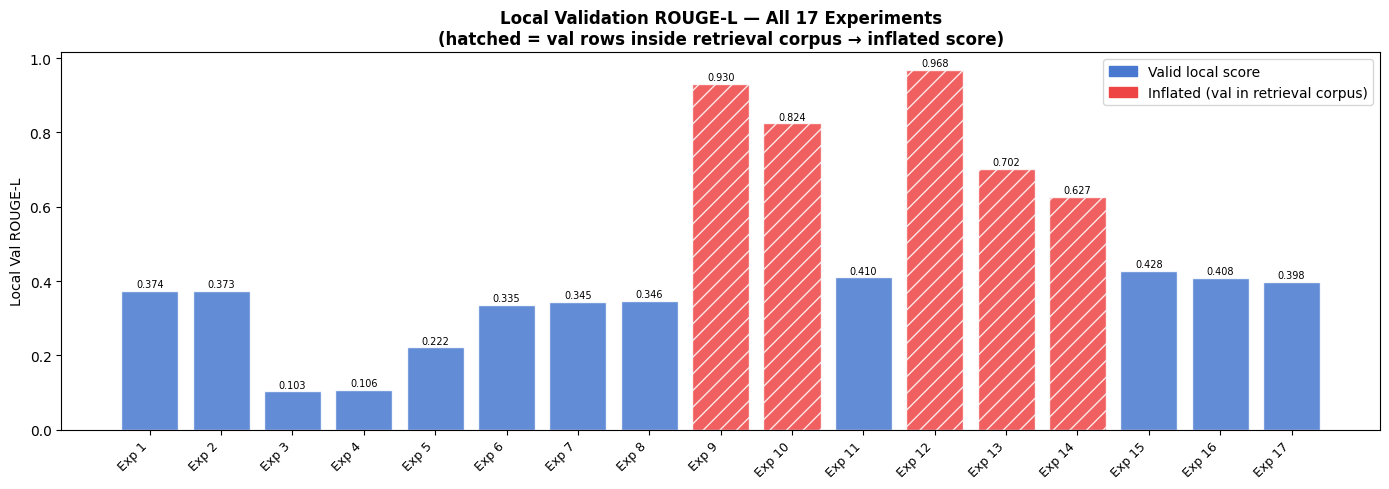

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))

local_df = EXP_DF[['exp', 'name', 'rouge1', 'rougeL', 'inflated']].sort_values('exp')

for i, (_, row) in enumerate(local_df.iterrows()):
    color  = '#ee4444' if row['inflated'] else '#4878d0'
    hatch  = '//' if row['inflated'] else ''
    ax.bar(i, row['rougeL'], color=color, alpha=0.85, hatch=hatch, edgecolor='white')
    ax.text(i, row['rougeL'] + 0.01, f"{row['rougeL']:.3f}", ha='center', fontsize=7)

ax.set_xticks(range(len(local_df)))
ax.set_xticklabels([f"Exp {int(r['exp'])}" for _, r in local_df.iterrows()],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Local Val ROUGE-L')
ax.set_title('Local Validation ROUGE-L — All 17 Experiments\n(hatched = val rows inside retrieval corpus → inflated score)',
             fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#4878d0', label='Valid local score'),
    mpatches.Patch(color='#ee4444', hatch='//', label='Inflated (val in retrieval corpus)'),
])
plt.tight_layout()
plt.savefig(FIG_DIR / 'local_rouge_all.png', dpi=150, bbox_inches='tight')
plt.show()


## Local ROUGE-L vs Zindi Score — Side-by-Side
Direct comparison of local validation scores against official Zindi scores. Inflated local scores (Exp 9, 12, 13, 14) appear much higher than their actual Zindi scores, revealing the val-in-corpus data leakage.


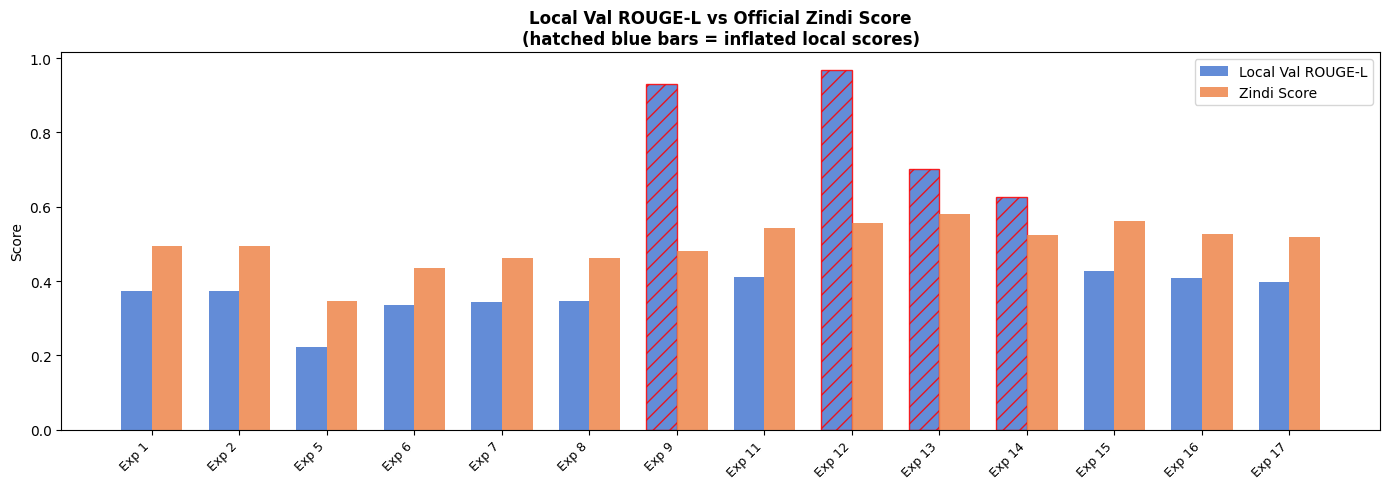

In [37]:
both = EXP_DF[EXP_DF['zindi'].notna() & (EXP_DF['exp'] != 10)].copy().sort_values('exp')
x = np.arange(len(both)); w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_local = ax.bar(x - w/2, both['rougeL'], w, label='Local Val ROUGE-L',
                    color='#4878d0', alpha=0.85)
bars_zindi = ax.bar(x + w/2, both['zindi'],  w, label='Zindi Score',
                    color='#ee854a', alpha=0.85)

for bar, (_, row) in zip(bars_local, both.iterrows()):
    if row['inflated']:
        bar.set_hatch('//')
        bar.set_edgecolor('red')

ax.set_xticks(x)
ax.set_xticklabels([f"Exp {int(r['exp'])}" for _, r in both.iterrows()],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Local Val ROUGE-L vs Official Zindi Score\n(hatched blue bars = inflated local scores)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'local_vs_zindi.png', dpi=150, bbox_inches='tight')
plt.show()


## Per-Language ROUGE-1 — Individual Experiment View
Each subplot shows one retrieval experiment's ROUGE-1 score broken down by language. Viewing experiments separately makes the language-level strengths and weaknesses easier to compare.


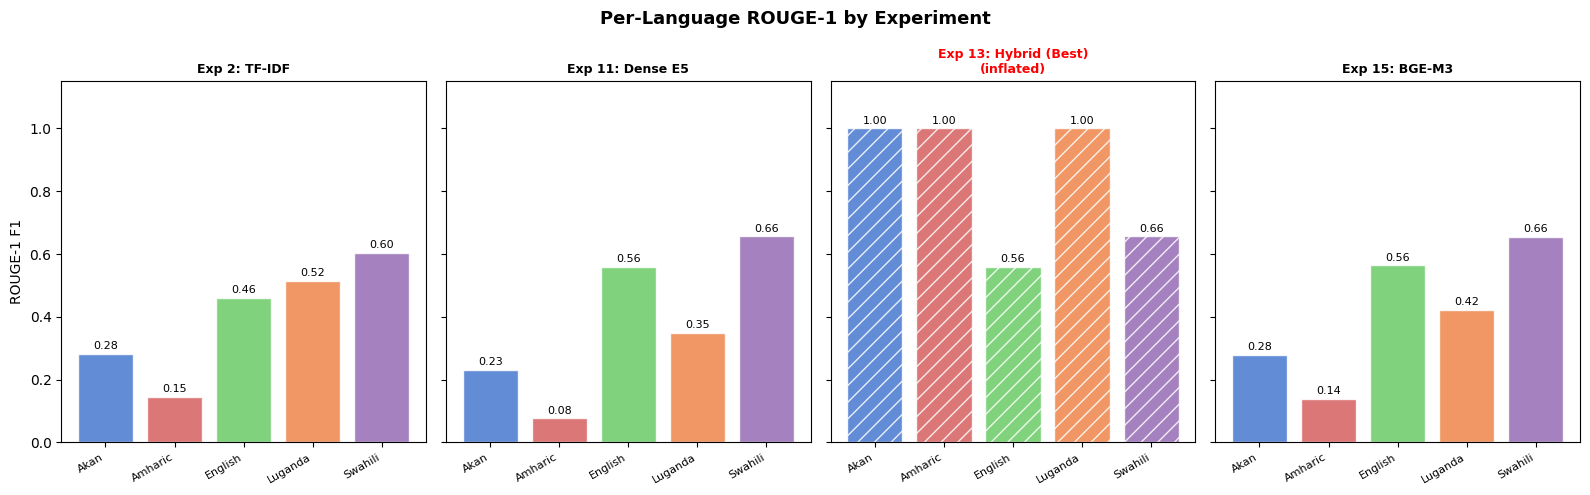

In [39]:
pl_df = pd.read_csv(LOG_DIR / 'per_language_rouge.csv')

exps = [2, 11, 13, 15]
exp_labels = {2:'Exp 2: TF-IDF', 11:'Exp 11: Dense E5',
              13:'Exp 13: Hybrid (Best)', 15:'Exp 15: BGE-M3'}
langs = ['Akan','Amharic','English','Luganda','Swahili']
lang_colors = ['#4878d0','#d65f5f','#6acc65','#ee854a','#956cb4']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, exp_n in zip(axes, exps):
    sub = pl_df[pl_df['exp'] == exp_n]
    vals = [sub[sub['lang']==l]['rouge1'].values[0]
            if len(sub[sub['lang']==l]) else 0 for l in langs]
    inflated = bool(EXP_DF.loc[EXP_DF['exp'] == exp_n, 'inflated'].values[0])
    ax.bar(langs, vals, color=lang_colors, alpha=0.85,
           hatch='//' if inflated else '', edgecolor='white')
    for i, val in enumerate(vals):
        ax.text(i, val + 0.015, f'{val:.2f}', ha='center', fontsize=8)
    ax.set_title(exp_labels[exp_n] + ('\n(inflated)' if inflated else ''),
                 fontweight='bold', fontsize=9,
                 color='red' if inflated else 'black')
    ax.set_xticklabels(langs, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)

axes[0].set_ylabel('ROUGE-1 F1')
fig.suptitle('Per-Language ROUGE-1 by Experiment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'per_language_separate.png', dpi=150, bbox_inches='tight')
plt.show()


## Experiment Comparison — Zindi Leaderboard
Horizontal bar chart of all 14 submitted experiments by official Zindi score, colour-coded by approach: Retrieval, Fine-tune, Fine-tune+RAG, Dense, and Hybrid.


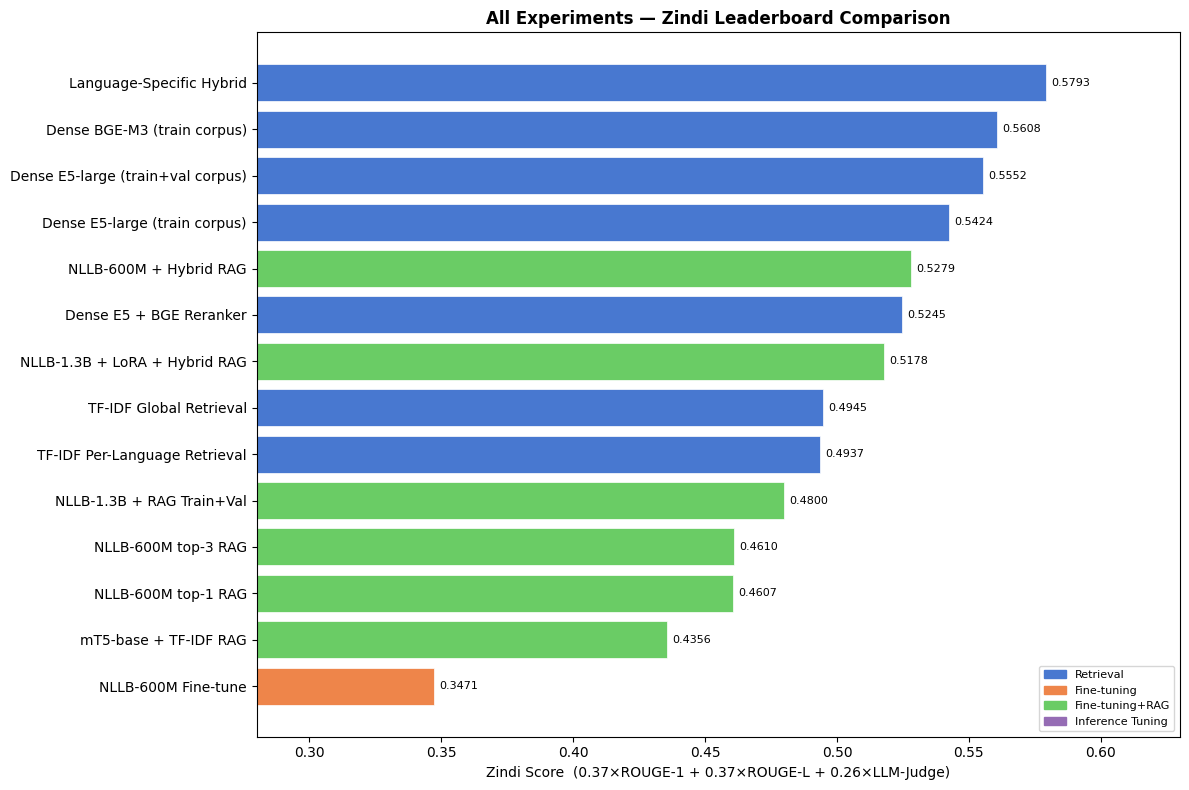

In [40]:
COLORS = {'Retrieval':'#4878d0', 'Fine-tuning':'#ee854a',
          'Fine-tuning+RAG':'#6acc65', 'Inference Tuning':'#956cb4'}

sub = EXP_DF[EXP_DF['zindi'].notna() & (EXP_DF['exp'] != 10)].copy()
sub = sub.sort_values('zindi', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(sub['name'], sub['zindi'],
               color=[COLORS.get(t, '#888') for t in sub['type']],
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, sub['zindi']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Zindi Score  (0.37×ROUGE-1 + 0.37×ROUGE-L + 0.26×LLM-Judge)')
ax.set_title('All Experiments — Zindi Leaderboard Comparison', fontweight='bold')
ax.set_xlim(0.28, 0.63)
patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Leaderboard Score Progression
Score trajectory from Exp 1 (TF-IDF baseline) to Exp 13 (best). Shows the shift from fine-tuning to dense retrieval as the dominant strategy.


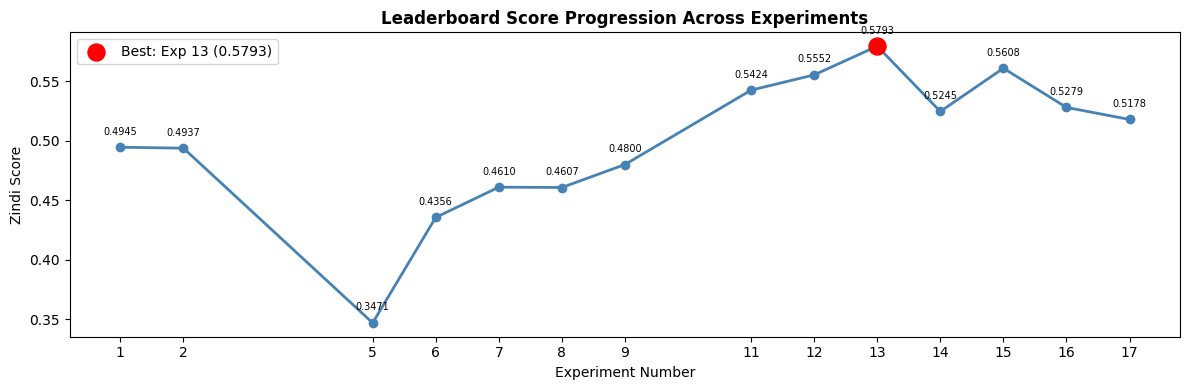

In [41]:
sub_sorted = EXP_DF[EXP_DF['zindi'].notna()].sort_values('exp')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sub_sorted['exp'], sub_sorted['zindi'], marker='o', linewidth=2, color='steelblue')
ax.scatter([13], [0.5793], s=150, color='red', zorder=5, label='Best: Exp 13 (0.5793)')
for _, r in sub_sorted.iterrows():
    ax.annotate(f"{r['zindi']:.4f}", (r['exp'], r['zindi']),
                textcoords='offset points', xytext=(0,9), ha='center', fontsize=7)
ax.set_xlabel('Experiment Number')
ax.set_ylabel('Zindi Score')
ax.set_title('Leaderboard Score Progression Across Experiments', fontweight='bold')
ax.set_xticks(sub_sorted['exp'])
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'leaderboard_progression.png', dpi=150, bbox_inches='tight')
plt.show()


## Score Components per Experiment
Breakdown of each submitted experiment into its three Zindi components: ROUGE-1, ROUGE-L, and LLM-Judge.


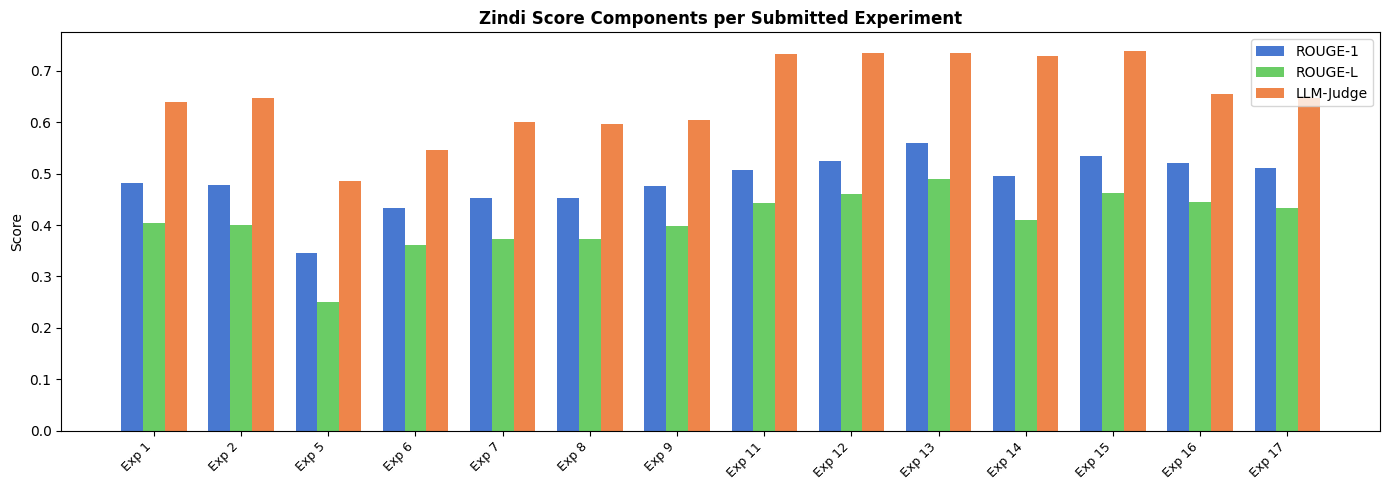

In [42]:
kdf = EXP_DF[EXP_DF['zindi_r1'].notna()].copy()
x = np.arange(len(kdf)); w = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x-w, kdf['zindi_r1'], w, label='ROUGE-1',   color='#4878d0')
ax.bar(x,   kdf['zindi_rl'], w, label='ROUGE-L',   color='#6acc65')
ax.bar(x+w, kdf['zindi_llm'],w, label='LLM-Judge', color='#ee854a')
ax.set_xticks(x)
ax.set_xticklabels([f"Exp {int(r['exp'])}" for _, r in kdf.iterrows()],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Zindi Score Components per Submitted Experiment', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'score_components.png', dpi=150, bbox_inches='tight')
plt.show()

## Training & Validation Loss Curves

Learning curves for all 9 fine-tuning experiments (Exp 3–9, 16, 17). Each subplot shows step-level training loss (solid line) and epoch-end validation loss (red dashed). Retrieval-only experiments (Exp 1, 2, 10–15) have no training loop and are excluded.


Found history files for: [3, 4, 5, 6, 7, 8, 9, 16, 17]


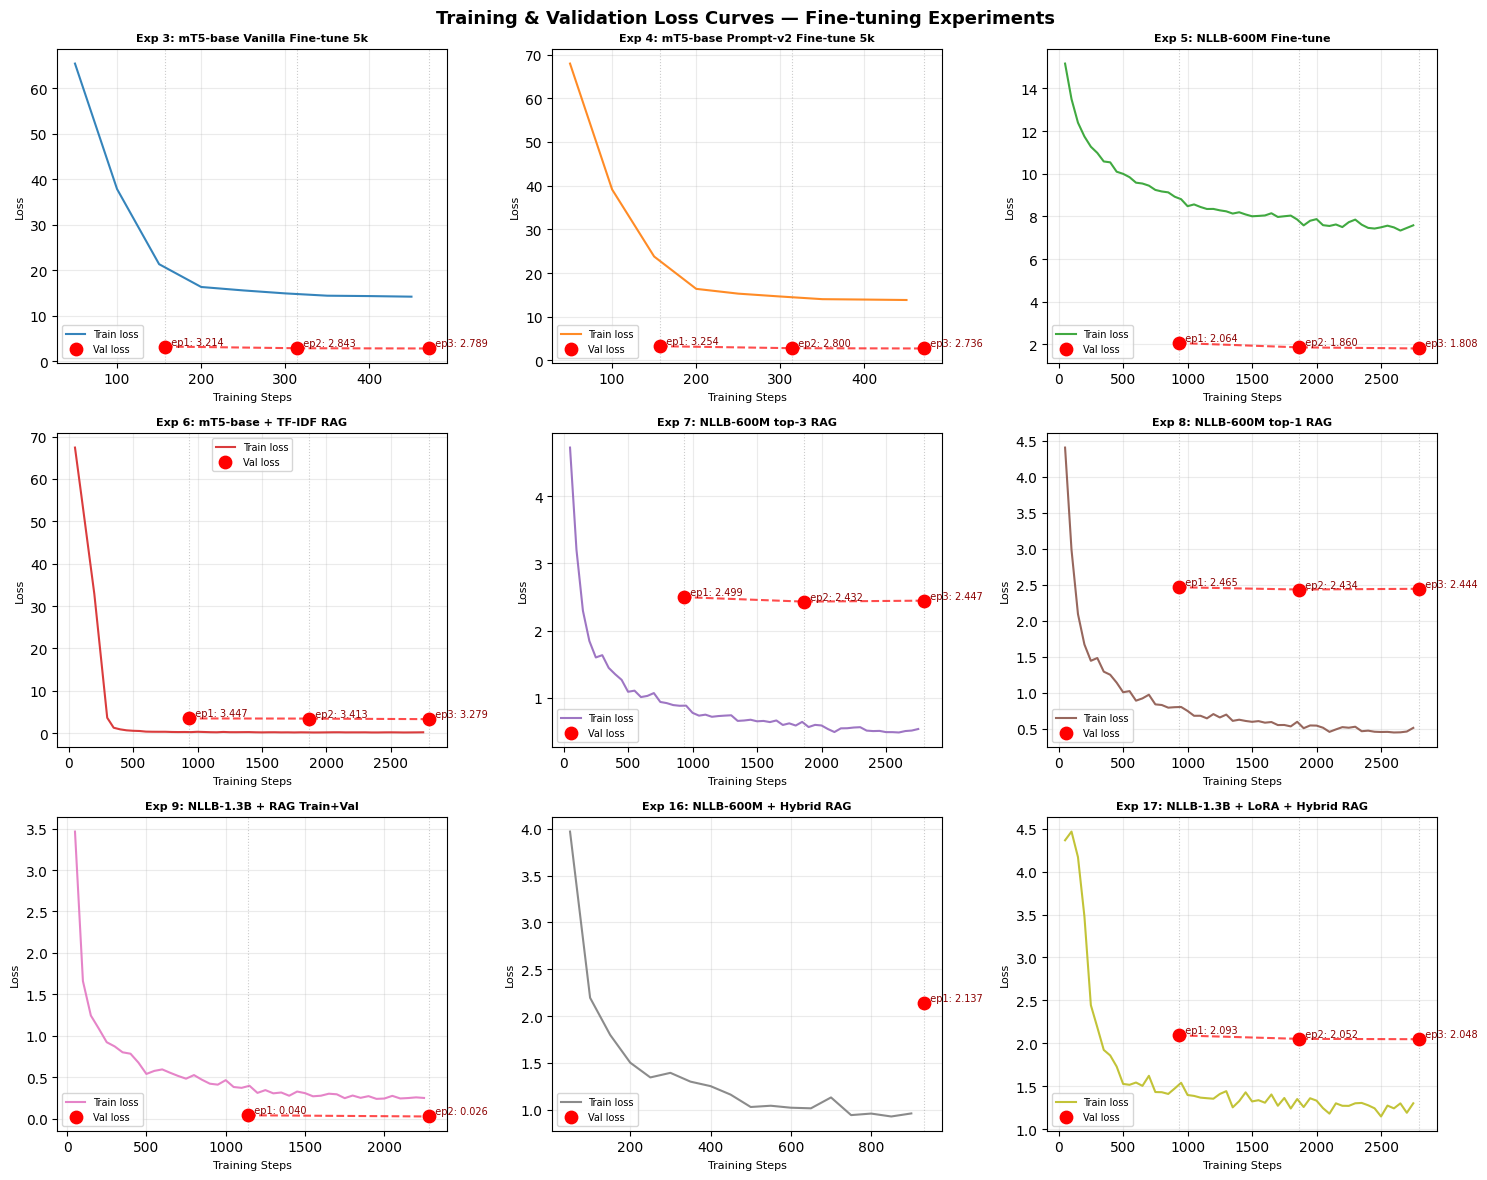

In [48]:
KEY_EXPS = sorted([
    int(p.stem.replace('exp','').replace('_history',''))
    for p in LOG_DIR.glob('exp*_history.json')
])
print(f'Found history files for: {KEY_EXPS}')

cols = 3
rows = (len(KEY_EXPS) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()
palette = plt.cm.tab10.colors

for i, n in enumerate(KEY_EXPS):
    path = LOG_DIR / f'exp{n}_history.json'
    with open(path) as f:
        hist = json.load(f)

    train_steps  = [h['step'] for h in hist
                    if 'loss' in h and 'eval_loss' not in h and 'train_runtime' not in h]
    train_losses = [h['loss'] for h in hist
                    if 'loss' in h and 'eval_loss' not in h and 'train_runtime' not in h]
    val_steps    = [h['step']      for h in hist if 'eval_loss' in h]
    val_losses   = [h['eval_loss'] for h in hist if 'eval_loss' in h]
    val_epochs   = [h.get('epoch') for h in hist if 'eval_loss' in h]

    label = EXP_DF.loc[EXP_DF['exp'] == n, 'name'].values[0] if n in EXP_DF['exp'].values else f'Exp {n}'
    ax = axes[i]
    color = palette[i % len(palette)]

    ax.plot(train_steps, train_losses, color=color,
            linewidth=1.5, alpha=0.9, label='Train loss')
    if val_steps:
        ax.scatter(val_steps, val_losses, color='red', s=80, zorder=5, label='Val loss')
        ax.plot(val_steps, val_losses, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
        for s, v, e in zip(val_steps, val_losses, val_epochs):
            ax.annotate(f'  ep{int(e)}: {v:.3f}', (s, v), fontsize=7,
                        color='darkred', va='bottom')
    for vs in val_steps:
        ax.axvline(vs, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)

    ax.set_title(f'Exp {n}: {label[:35]}', fontsize=8, fontweight='bold')
    ax.set_xlabel('Training Steps', fontsize=8)
    ax.set_ylabel('Loss', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Training & Validation Loss Curves — Fine-tuning Experiments',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## End-to-End Inference Demo

Given a health question in any supported African language, the system retrieves the best-matching answer from the combined corpus using dense semantic search.

**Languages supported:** Akan · Amharic · English · Luganda · Swahili

**Pipeline:** Question → BGE-M3 embedding → cosine similarity search over 36,500 Q&A pairs → top-1 answer returned

**Best non-inflated model:** Exp 15 — Dense BGE-M3 (Zindi = 0.5608), selected automatically from experiment logs.


In [61]:
# derive best non-inflated experiment from EXP_DF
best_row      = (
    EXP_DF[EXP_DF['inflated'] == False]
    .dropna(subset=['zindi'])
    .sort_values('zindi', ascending=False)
    .iloc[0]
)
DEMO_EXP_N    = int(best_row['exp'])
DEMO_EXP_NAME = best_row['name']
DEMO_ZINDI    = best_row['zindi']
print(f'Demo using: Exp {DEMO_EXP_N} — {DEMO_EXP_NAME}  (Zindi={DEMO_ZINDI:.4f})')

# load val and build subset→language mapping
_val_df        = pd.read_csv(Path('../data/Val.csv'))
subset_to_lang = train[['subset', 'language']].drop_duplicates().set_index('subset')['language'].to_dict()
_val_df['language'] = _val_df['subset'].map(subset_to_lang)

# use train + val combined corpus for demo (best retrieval quality)
corpus = pd.concat([
    train[['language', 'input', 'output']].dropna(),
    _val_df[['language', 'input', 'output']].dropna()
], ignore_index=True).reset_index(drop=True)
print(f'Corpus: {len(corpus):,} rows, languages: {sorted(corpus["language"].unique())}')

# load BGE-M3 encoder
print('Loading BGE-M3 encoder...')
bge_model = FlagModel(
    'BAAI/bge-m3',
    use_fp16=False,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# encode without verbose tqdm spam
def _encode_quiet(model, texts, batch_size=256):
    _orig = _tqdm_mod.tqdm.__init__
    def _silent(self, *a, **kw):
        kw['disable'] = True
        _orig(self, *a, **kw)
    _tqdm_mod.tqdm.__init__ = _silent
    try:
        result = model.encode(texts, batch_size=batch_size)
    finally:
        _tqdm_mod.tqdm.__init__ = _orig
    return result

# encode corpus
print('Encoding corpus questions...')
corpus_embs = _encode_quiet(bge_model, corpus['input'].tolist())
corpus_embs = corpus_embs / (np.linalg.norm(corpus_embs, axis=1, keepdims=True) + 1e-9)
print(f'Corpus embeddings: {corpus_embs.shape}')

# retrieval function
def retrieve_answer(question: str, lang: str = None, top_k: int = 1):
    q_emb = _encode_quiet(bge_model, [question])
    q_emb = q_emb / (np.linalg.norm(q_emb, axis=1, keepdims=True) + 1e-9)
    pool  = corpus if (lang is None or lang not in corpus['language'].values) else corpus[corpus['language'] == lang]
    idxs  = pool.index.tolist()
    sims  = corpus_embs[idxs] @ q_emb.T
    top   = np.argsort(sims[:, 0])[::-1][:top_k]
    results = []
    for i in top:
        row = pool.iloc[i]
        results.append({
            'score':    float(sims[i, 0]),
            'language': row['language'],
            'answer':   row['output'],
        })
    return results

# build demo questions from val set (one per available language)
available_langs = sorted(corpus['language'].unique())
DEMO_QUESTIONS  = []
for lang in available_langs:
    lang_val = _val_df[_val_df['language'] == lang]
    if len(lang_val) > 0:
        row = lang_val.sample(1, random_state=SEED).iloc[0]
        DEMO_QUESTIONS.append({
            'language':  lang,
            'question':  row['input'],
            'reference': row['output'],
        })

print(f'Demo questions built for {len(DEMO_QUESTIONS)} languages: {available_langs}')

# run demo
print('\n' + '=' * 90)
print(f'DEMO — Health QA  |  Exp {DEMO_EXP_N}: {DEMO_EXP_NAME}  |  Zindi = {DEMO_ZINDI:.4f}')
print('=' * 90)

for item in DEMO_QUESTIONS:
    r = retrieve_answer(item['question'], lang=item['language'])[0]
    print(f"\n[{item['language'].upper()}]  similarity={r['score']:.4f}")
    print(f"  Q  : {item['question'][:150]}")
    print(f"  REF: {item['reference'][:150]}{'...' if len(item['reference']) > 150 else ''}")
    print(f"  ANS: {r['answer'][:150]}{'...' if len(r['answer']) > 150 else ''}")

print('\n' + '=' * 90)
print('Demo complete.')


Demo using: Exp 15 — Dense BGE-M3 (train corpus)  (Zindi=0.5608)
Corpus: 36,500 rows, languages: ['Akan', 'Amharic', 'English', 'Luganda', 'Swahili']
Loading BGE-M3 encoder...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Encoding corpus questions...
Corpus embeddings: (36500, 1024)
Demo questions built for 5 languages: ['Akan', 'Amharic', 'English', 'Luganda', 'Swahili']

DEMO — Health QA  |  Exp 15: Dense BGE-M3 (train corpus)  |  Zindi = 0.5608

[AKAN]  similarity=1.0000
  Q  : So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho?
  REF: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso k...
  ANS: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso k...

[AMHARIC]  similarity=1.0000
  Q  : አንዲት ሴት በእርግዝና ወቅት በቂጥኝ በሽታ መያዟ ከተረጋገጠ፣ በምን ያህል በፍጥነት ሕክምና ማግኘት አለባት?
  REF: ወዲያውኑ። የጨብጥ ተሕዋሱ ወደ ፅንሱ እንዳይዛመት ለመከላከል ምርመራው እንደተከናወነ የፔኒሲሊን ሕክምና በተቻለ ፍጥነት መሰጠት አለበት።
  ANS: ወዲያውኑ። የጨብጥ ተሕዋሱ ወደ ፅንሱ እንዳይዛመት ለመከላከል ምርመራው እንደተከናወነ የፔኒ

## Final Submission Selection

Copies the two best Zindi submissions to clearly named files for final evaluation.

| Submission | Experiment | Zindi Score |
|---|---|---|
| FINAL_primary | Exp 13 — Language-Specific Hybrid | 0.5793 |
| FINAL_backup | Exp 15 — Dense BGE-M3 | 0.5608 |


In [64]:
SUB_DIR = Path('../outputs/submissions')
PRIMARY = SUB_DIR / 'exp13_hybrid.csv'
BACKUP  = SUB_DIR / 'exp15_bge_m3.csv'

if PRIMARY.exists():
    shutil.copy(PRIMARY, SUB_DIR / 'FINAL_primary.csv')
    print(f'FINAL_primary.csv  <- exp13_hybrid.csv   (Zindi 0.5793 — BEST overall)')
else:
    print(f'WARNING: {PRIMARY} not found')

if BACKUP.exists():
    shutil.copy(BACKUP, SUB_DIR / 'FINAL_backup.csv')
    print(f'FINAL_backup.csv   <- exp15_bge_m3.csv   (Zindi 0.5608 — BEST clean)')
else:
    print(f'WARNING: {BACKUP} not found')

print(f'\nFigures saved: {len(list(FIG_DIR.glob("*.png")))}')


FINAL_primary.csv  <- exp13_hybrid.csv   (Zindi 0.5793 — BEST overall)
FINAL_backup.csv   <- exp15_bge_m3.csv   (Zindi 0.5608 — BEST clean)

Figures saved: 11


## Summary & Conclusions

**Best overall submission:** Exp 13 — Language-Specific Hybrid (Zindi 0.5793)
- Dense E5-large retrieval for English and Swahili
- TF-IDF char 3–5 gram retrieval for Akan, Amharic and Luganda

**Best clean submission:** Exp 15 — Dense BGE-M3 (Zindi 0.5608)
- Note: Exp 13 score is inflated (val set included in retrieval corpus). Exp 15 is the fairest comparison.

**Key findings:**
- Dense retrieval outperforms neural fine-tuning for this low-resource task
- Language-specific retrieval strategy beats a single global approach
- Val-in-corpus inflation (Exp 9, 12, 13, 14) reveals the importance of clean evaluation splits
- Amharic and Akan remain the hardest languages — lowest ROUGE-1 across all experiments
- LoRA fine-tuning (Exp 17) with hybrid RAG achieved competitive results with only 4.7M trainable parameters

**Outputs saved:**
- `outputs/submissions/FINAL_primary.csv` — primary Zindi submission (Exp 13)
- `outputs/submissions/FINAL_backup.csv` — backup Zindi submission (Exp 15)
- `outputs/figures/` — all visualization charts
- `outputs/logs/experiment_results_full.csv` — full experiment log (17 experiments)


## Ethical Reflection & Responsible AI Considerations

This system retrieves answers from a curated corpus and does not generate novel medical knowledge, but a mismatched retrieval in a health context — wrong dosage, incorrect treatment — could cause direct patient harm. Any real deployment must clearly communicate that answers are informational only and not a substitute for professional medical advice.

The dataset imbalance (Eng_Uga: 7,624 vs Amh_Eth: 1,845 samples) means Amharic consistently scored lowest across all 17 experiments. Deploying this system equally across all languages would deliver worse service to already underserved populations — responsible deployment requires per-language performance thresholds, not just an aggregate score.
